# Модель для предсказания массы морских черепах

- Автор: Евдокимов Александр
- Дата: 10.08.26

---

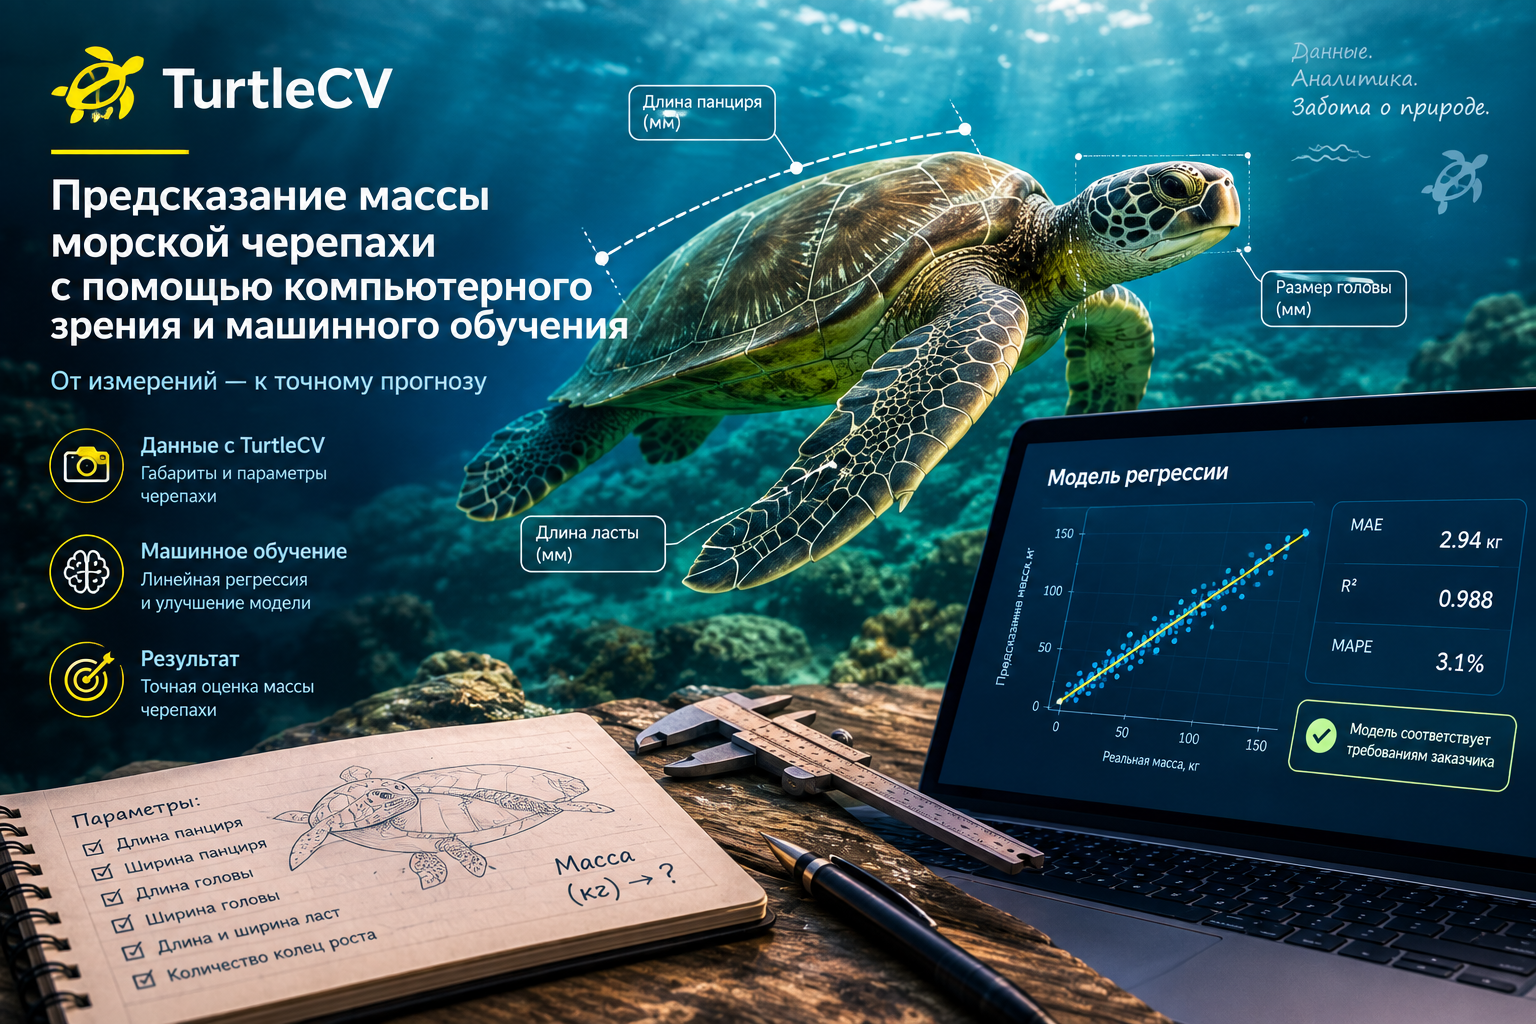

<a id='p1'></a>

---

## Постановка задачи машинного обучения

<span style="font-size: 18px;">**Цель проекта:**</span>

Разработать модель, которая по результатам портативной системы компьютерного зрения TurtleCV о габаритах черепахи, а также некоторым другим данным будет предсказывать массу черепахи.

<span style="font-size: 18px;">**Задачи проекта:**</span>

В рамках указанной цели необходимо решать задачу регрессии. Для ее решения необходимо:
- зарузить данные и провести исследовательский анализ данных; 
- осуществить предобработку данных (поиск и исправление аномалий в данных, категоризация и масштабирование признаков);
- разделить выборку на обучающую, валидационную и тестовую выборки (20% от предоставленных в датасете наблюдений), целевой перемнной является масса черепахи, кг;
- обучить модели на тренировочной выборке;
- определить гиперпараметры на валидационной выборке, используя метрики качества MAE (основная), дополнительные - MSE, RMSE, R², MAPE;
- финальная оценка качества, а также подведение итогов и указание рекомендаций.

**Основные требования к продукту**

- Модель должна быть линейной, чтобы полученные коэффициенты в дальнейшем использовать для простой функции прогнозирования.
- Для целевой популяции зелёных морских черепах массой от 50 до 150 килограмм приемлемая метрика MAE в случае взрослых особей — не более 5 кг. Опирайтесь на этот критерий при отборе модели.
- Модель должна уметь предсказывать массу черепах разного возраста и, соответственно, размера. Выходит, значимая ошибка модели зависит от масштаба признаков, поэтому необходимо оценить модель и метрикой, демонстрирующей среднюю ошибку в относительном значении, — MAPE.
- Модель должна достичь высокого значения R², то есть объяснять большую часть вариативности массы. Значение метрики должно быть не меньше 0.97 на валидационной и тестовой выборках для лучшей модели, рекомендуемой к внедрению.
- В тестовой выборке должно быть 20% от предоставленных в датасете наблюдений.
- Необходимо обеспечить воспроизводимость экспериментов, фиксируя везде, где это необходимо, начальное состояние генераторов случайных чисел random_state.

<span style="font-size: 18px;">**Описание данных**</span>

Выгрузка из базы данных содержит следующие данные:

Данные хранятся в CSV-файле. Они содержат следующие поля:
- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.

Немного деталей о биологии морских черепах. Щитки, из которых состоит панцирь, нарастают по краям, образуя на себе кольца, похожие на годичные кольца деревьев. Скорость появления и ширина этих колец зависят от условий жизни и возраста особи, а их общее количество в некоторой степени коррелирует с возрастом животного, а возраст, в свою очередь, с размерами и массой черепахи. В первые два года жизни на панцире могут появиться до пяти колец в год, в последующие годы — по 2–3 кольца в год.
Уже после получения датасета представители заказчика переслали вам сообщение одного из сотрудников с дополнительной информацией.

**Замечание:** некоторые значения могут быть умножены на 10, т.к. данные были внесены ошибочно в сантиметрах.

<a id='contents'></a>

---

<span style="font-size: 18px;">**Содержимое проекта**</span>

1. [Постановка задачи машинного обучения](#p1)
2. [Подключение и настройка библиотек](#p2)
3. [Загрузка датасета](#p3), а также [отчет](#p3a) по разделу
4. Исследовательский анализ данных
    - [Фильтрация датафрейма](#p4a)
    - [Удаление столбцов](#p4b)
    - [Обработка пропусков и дубликатов](#p4c)
    - [Распределение признаков](#p4d)
    - [Корреляция между признаками](#p4e)
    - [Отчет по итогам раздела](#p4f)
5. [Предобработка данных](#p5)
6. Обучение моделей
    - [Базовая модель (`dummy_mod`)](#p6)
    - [Наивная модель (`naive_mod`)](#p6b)
    - [Аналитическая лейная регрессия для полного набора признаков (`standart_LR`)](#p6c)
    - [Lasso - модель (`Lasso`)](#p6d)
    - [Ridge - модель (`Ridge`)](#p6e)
    - [SGDRegressor-модель (`SGDRegressor`)](#p6f)
    - [Модель с полиномами более высоких порядков (`Polynomial_model`)](#p6g)
7. [Сравнение моделей на валидационной выборке](#p7)
8. [Проверка лучшей модели на тестовой выборке](#p8)
9. [Оценка важности признаков](#p9)
10. [Сохранение артефактов модели](#p10)
11. [Общие выводы и рекомендации по дальнейшей работе](#p11)

<a id='p2'></a>

---

## Подключение и настройка библиотек

[К Содержимому проекта](#contents)

In [1]:
# Для установки необходимых библиотек
# !pip install phik -U

!pip freeze > "./../requirements.txt"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import joblib

In [3]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

<a id='p3'></a>

---

## Загрузка датасета

[К Содержимому проекта](#contents)

In [4]:
class color:
    """
    Класс для форматирования текста в терминале
    """

    PURPLE = "\033[95m"
    CYAN = "\033[96m"
    DARKCYAN = "\033[36m"
    BLUE = "\033[94m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED = "\033[91m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    END = "\033[0m"  # сбросить все стили (возврат к нормальному виду)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
    
df_initial = pd.read_csv('./../datasets/turtles.csv', sep = '\t')
print(color.BOLD + color.BLUE + 'Первые пять строк:' + color.END)
display(df_initial.head())
print(color.BOLD + color.BLUE + '\nПоследние пять строк:' + color.END)
display(df_initial.tail())
print(color.BOLD + color.BLUE + '\nСлучайные пять строк:' + color.END)
display(df_initial.sample(n=5, random_state = 42))

Первые пять строк:


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,"3,0",NaN,1703159226,"87,687"
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,"1,0",1.0,1689428175,"26,949"
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,"3,0",NaN,1745783111,"30,016"
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,"4,0",1.0,1677757151,"33,917"
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,"4,0",1.0,1744455613,"28,511"



Последние пять строк:


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8856,20419,Chelonia mydas,f8e7eeb2bf983e45babf191d9f77be92,1241.0,1010,210.0,272.0,597,640,724,618,598.0,475.0,504.0,492.0,115,"1,0",5.0,1703051561,"121,688"
8857,24958,Dermochelys coriacea,de92c7be44d53150a4fe5b20ceba08e7,1658.0,830,266.0,153.0,1655,785,1680,943,1237.0,580.0,1369.0,662.0,16,"3,0",NaN,1748547819,"418,0"
8858,23435,Lepidochelys olivacea,7d65c2b1a5750da62fb459cf4020887d,356.0,298,63.0,61.0,240,213,268,172,202.0,137.0,227.0,175.0,0,"1,0",NaN,1734257248,"27,876"
8859,21143,Chelonia mydas,6d4abbb15e0284aeeff2b36ce501ea16,941.0,836,123.0,139.0,565,401,632,431,477.0,349.0,428.0,413.0,86,"2,0",NaN,1710678299,"80,451"
8860,24105,Lepidochelys olivacea,63f8cd4da22a5f8e43d68cbb22d5c784,566.0,401,68.0,93.0,404,356,427,314,339.0,254.0,274.0,212.0,14,"4,0",NaN,1740421099,"35,242"



Случайные пять строк:


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
6282,18472,Chelonia mydas,72225e27192766a640c14c94949c5d4d,1466.0,1300,289.0,196.0,927,786,721,775,623.0,590.0,601.0,569.0,97,"2,0",3.0,1683156827,"166,651"
6516,20464,lepidochelys olivacea,8def87260ed8fd5c3e96b1f3ede23ffe,391.0,298,63.0,57.0,268,222,322,160,212.0,152.0,218.0,150.0,0,"3,0",NaN,1703512227,"28,212"
5953,20025,Lepidochelys olivacea,f7149469c2a61ee615ecc4f93b955524,357.0,243,48.0,45.0,287,197,274,184,187.0,167.0,196.0,154.0,0,"4,0",1.0,1699438150,"26,959"
4891,23408,Lepidochelys olivacea,8462bc874482be87d1d93c424d413f00,537.0,425,73.0,84.0,379,311,347,327,292.0,302.0,253.0,234.0,6,"1,0",NaN,1733925092,"35,606"
222,18062,Lepidochelys olivacea,ab7fd8cd0531b738d45294cc500b7c0a,376.0,296,63.0,62.0,245,195,281,253,240.0,160.0,255.0,183.0,0,"4,0",NaN,1678971889,"28,793"


In [5]:
df_initial.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

**Замечание:**

Заметны расхождени типов с ожидаемыми, преобразуем. В `timestamp` скорее всего Unix-дата. Этот столбец вряд-ли будет нужен, но преобразовать не сложно. Кроме того подправим имя столбца `registration number` приведя его к snake_case.

In [6]:
df_initial['measure_count'] = pd.to_numeric(df_initial['measure_count'].str.replace(',', '.'), errors='coerce', downcast='float').astype('Int64')
df_initial['timestamp'] = pd.to_datetime(df_initial['timestamp'], unit='s')
df_initial['weight'] = pd.to_numeric(df_initial['weight'].str.replace(',', '.'), errors='coerce', downcast='float')

df_initial.columns = df_initial.columns.str.lower()
df_initial.columns = df_initial.columns.str.replace(' ', '_')

**Итого** после начального преобразования типов:

In [7]:
print(color.BOLD + color.BLUE + '\nСлучайные четыре строки:' + color.END)
display(df_initial.sample(n=4, random_state = 42))
print(color.BOLD + color.BLUE + '\nОсновая информация по датасету:\n' + color.END)
df_initial.info()
print(color.BOLD + color.BLUE + '\nДополнительная информация по датасету:\n' + color.END)
display(df_initial.describe().T)


Случайные четыре строки:


,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
6282,18472,Chelonia mydas,72225e27192766a640c14c94949c5d4d,1466.0,1300,289.0,196.0,927,786,721,775,623.0,590.0,601.0,569.0,97,2,3.0,2023-05-03 23:33:47,166.651001
6516,20464,lepidochelys olivacea,8def87260ed8fd5c3e96b1f3ede23ffe,391.0,298,63.0,57.0,268,222,322,160,212.0,152.0,218.0,150.0,0,3,NaN,2023-12-25 13:50:27,28.212000
5953,20025,Lepidochelys olivacea,f7149469c2a61ee615ecc4f93b955524,357.0,243,48.0,45.0,287,197,274,184,187.0,167.0,196.0,154.0,0,4,1.0,2023-11-08 10:09:10,26.959000
4891,23408,Lepidochelys olivacea,8462bc874482be87d1d93c424d413f00,537.0,425,73.0,84.0,379,311,347,327,292.0,302.0,253.0,234.0,6,1,NaN,2024-12-11 13:51:32,35.605999



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   id                   8861 non-null   int64        
 1   binomial_name        8812 non-null   str          
 2   registration_number  8832 non-null   str          
 3   shell_length         8774 non-null   float64      
 4   shell_width          8861 non-null   int64        
 5   head_length          8715 non-null   float64      
 6   head_width           8715 non-null   float64      
 7   flipper_length_1     8861 non-null   int64        
 8   flipper_width_1      8861 non-null   int64        
 9   flipper_length_2     8861 non-null   int64        
 10  flipper_width_2      8861 non-null   int64        
 11  flipper_length_3     8760 non-null   float64      
 12  flipper_width_3      8760 non-null   float64      
 13  flipper_length_4     8760

,count,mean,min,25%,50%,75%,max,std
id,8861.0,21359.335628,17438.0,19396.0,21357.0,23317.0,25279.0,2263.08942
shell_length,8774.0,764.22202,132.0,440.0,635.0,951.0,20240.0,640.408681
shell_width,8861.0,598.832299,78.0,341.0,487.0,794.0,11550.0,480.970492
head_length,8715.0,123.341021,19.0,73.0,106.0,158.0,515.0,67.836566
head_width,8715.0,115.735169,12.0,67.0,98.0,156.0,382.0,62.326365
flipper_length_1,8861.0,497.551405,60.0,296.0,416.0,571.0,2875.0,353.575213
flipper_width_1,8861.0,380.594515,34.0,228.0,332.0,493.0,1479.0,214.481679
flipper_length_2,8861.0,498.22853,57.0,296.0,417.0,572.0,2967.0,355.074883
flipper_width_2,8861.0,380.687507,33.0,229.0,330.0,500.0,1402.0,213.485239
flipper_length_3,8760.0,397.953196,50.0,239.0,333.0,457.0,2279.0,282.970532


<a id='p3a'></a>

<span style="font-size: 18px;">**Отчет:**</span>

Датафрейм `turtles.csv` содержит 20 столбцов и 8861 строку, в которых представлена информация об измерениях черепах. В двух столбцах информация `measure_count` и `weight` данные автоматически были интерпретированы как строковые из-за наличия запятой в качестве разделителя. Они были преобразованы в числовые данные. Временная метка измерения `timestamp` хранилась в виде Unix-даты и была преобразована к типу `datetime64`. Имена столбцов в таблице соответствует стандарту snake_case. Пропуски, дубликаты и выбросы будут проверяться далее. Оптимизация типов также будет проведена позднее после чистки.

<a id='p4a'></a>

---

## Исследовательский анализ данных

Проведем исследовательский анализ данных:
1. Выясним, данные о каких черепахах представлены в датасете.
2. Проведем отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*.
3. Определим, все ли признаки можно использовать для решения задачи. Удалим признаки, которые никак не помогут.
4. Проверим, есть ли в данных пропуски. Определим, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки.
5. Определим, есть ли в данных дубликаты. Выберим корректный способ их обработки.
6. Проанализируем распределение признаков, построим необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определим, есть ли в данных выбросы и какие из них критичные. Решим, можно ли их сразу исправить.
7. Проверим, одинаков ли масштаб признаков.
8. Проанализируем корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определим, все ли признаки нужны для дальнейшей работы.
9. Проверим данные на мультиколлинеарность и решим, можно ли её устранить.

[К Содержимому проекта](#contents)

---

### Фильтрация датафрейма

[К Содержимому проекта](#contents)

In [8]:
# Удаляем пробелы в конец и в начале. Приводим к нижнему регистру
df_initial['binomial_name'] = df_initial['binomial_name'].str.strip()
df_initial['binomial_name'] = df_initial['binomial_name'].str.lower()
print(color.BOLD + color.BLUE + 'Колонка binomial_name:\n\n'  + color.END,df_initial['binomial_name'].unique())

Колонка binomial_name:

 <StringArray>
[       'caretta caretta',  'lepidochelys olivacea',         'chelonia mydas',
 'eretmochelys imbricata',   'dermochelys coriacea',                      nan,
    'lepidochelys kempii']
Length: 7, dtype: str


После преобразования в нижний регистр и удаления пробелов неявных дубликатов в название нет. Выделим требуемый вид, также исключим пропуски в целевой переменной:

In [9]:
df = df_initial.query("binomial_name == 'chelonia mydas'").copy()
num_row_before_clean = df.shape[0]
df = df.dropna(subset=['weight']).copy()
df = df.reset_index()
df = df.drop(["index"], axis=1)
print(color.BOLD + color.BLUE + '\nСлучайные четыре строки:' + color.END)
display(df.sample(n=4, random_state = 42))
print(color.BOLD + color.BLUE + '\nИнформация по датасету:' + color.END)
df.info()


Случайные четыре строки:


,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
1505,20560,chelonia mydas,1a52ecf25e4ee755392f5829735931f4,812.0,699,145.0,120.0,467,409,460,509,334.0,351.0,406.0,332.0,96,2,NaN,2024-01-05 14:03:05,66.391998
1378,23840,chelonia mydas,9069f4da7a73e547cc83923676b53e6f,784.0,753,128.0,127.0,485,456,435,425,384.0,379.0,378.0,342.0,70,1,NaN,2025-01-27 03:54:26,66.161003
1437,24487,chelonia mydas,a2e5c1cb40cfc55c7c416954e33605de,1342.0,1170,240.0,235.0,826,845,853,793,659.0,513.0,626.0,563.0,94,4,NaN,2025-04-05 18:35:17,154.891006
411,21788,chelonia mydas,4339f7c5968260d6f43cef167a407bb7,1215.0,1118,183.0,198.0,579,713,732,686,499.0,551.0,602.0,506.0,82,2,NaN,2024-06-02 00:07:44,133.132996



Информация по датасету:
<class 'pandas.DataFrame'>
RangeIndex: 2826 entries, 0 to 2825
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   id                   2826 non-null   int64        
 1   binomial_name        2826 non-null   str          
 2   registration_number  2822 non-null   str          
 3   shell_length         2791 non-null   float64      
 4   shell_width          2826 non-null   int64        
 5   head_length          2787 non-null   float64      
 6   head_width           2787 non-null   float64      
 7   flipper_length_1     2826 non-null   int64        
 8   flipper_width_1      2826 non-null   int64        
 9   flipper_length_2     2826 non-null   int64        
 10  flipper_width_2      2826 non-null   int64        
 11  flipper_length_3     2795 non-null   float64      
 12  flipper_width_3      2795 non-null   float64      
 13  flipper_length_4     2795 non-null

<a id='p4b'></a>

---

### Удаление столбцов

Исходя из целей и задачей разработки модели принято решение:
- Удалить столбец `id`, т.к. он не имеет связи или влияние на целевую перемонную `weight`.
- Удалить столбец `binomial_name`, т.к. в рамках исследования был оставлен один вид черепах.
- Удалить столбец `measure_count`, т.к. он имеет косвенную связь с `weight` и скорее связан с точностью измерения длин в выборке. Зависимость этого параметра и других стоит рассматривать в рамках отдельного исследования.
- Удалить столбцы `timestamp` и `registration_number`. Сами столбцы не должны иметь влияние на целевую переменную `weight`.
- Все перечисленные столбцы будут удалены позднее, после обработки дубликатов, пропусков и выбрасов.

Стоит также обратить внимание на пары признаков, описывающие длину и ширину панциря, головы, плавников (`shell_length` и `shell_width` и т.п.). Возможно, стоит попарно объединить в один признак, например, в виде площади соответствующей части тела. Такую площадь, в некотором приближении, можно оценить как эллипс, площадь эллипса: $S = \pi a b$, где $\pi$ - число, $a$ и $b$ - полуоси эллипса. В реалиях данных площадь поверхности панциря: $S \approx \pi * \text{ shell_length } * \text{ shell_width } * 0.25$. Коэффиициенты можно сократить и оставить только произведение длины на ширину. В итоге будет создано несколько датафреймов для теста, как с исходными столбцами, так и со столбцами заменителями.

[К Содержимому проекта](#contents)

<a id='p4c'></a>

---

### Обработка пропусков и дубликатов

Посмотрим на уникальные значения в столбцах.

[К Содержимому проекта](#contents)

In [10]:
print(color.BOLD + color.BLUE + 'Столбец и количество уникальных значений в нем:' + color.END)
display(df.nunique().sort_values(ascending=False))

missing_percentage = round(df.isna().sum() / len(df) * 100,2) 
missing_df = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков (%)': missing_percentage
})
print(color.BOLD + color.RED + "\nАнализ пропущенных значений (общее количество строк - " + str(df.shape[0]) + "):"  + color.END)
display(missing_df.sort_values(by='Количество пропусков', ascending=False))

Столбец и количество уникальных значений в нем:


id                     2486
timestamp              2486
registration_number    2482
weight                 2455
shell_length            798
shell_width             757
flipper_length_1        583
flipper_length_2        569
flipper_width_1         548
flipper_width_2         539
flipper_length_4        481
flipper_width_4         466
flipper_length_3        465
flipper_width_3         458
head_width              220
head_length             202
circle_count            101
shell_crack               5
measure_count             4
binomial_name             1
dtype: int64


Анализ пропущенных значений (общее количество строк - 2826):


,Количество пропусков,Процент пропусков (%)
shell_crack,2152,76.15
measure_count,81,2.87
head_width,39,1.38
head_length,39,1.38
shell_length,35,1.24
flipper_length_4,31,1.10
flipper_length_3,31,1.10
flipper_width_3,31,1.10
flipper_width_4,31,1.10
registration_number,4,0.14


Начнем с `shell_crack`. В случае остутствие каких-либо аномалий в имеющихся значениях и отсутствия 0 в значениях, его отсутствие вероятно означает отсутствие трещин, что в может быть интерпритировано как 0.

In [11]:
print(color.BOLD + color.BLUE + 'Колонка shell_crack:\n\n'  + color.END,df['shell_crack'].unique())

Колонка shell_crack:

 [ 1.  5. nan  3.  2.  4.]


In [12]:
df['shell_crack'] = df['shell_crack'].fillna(0)

Столбцы `measure_count` и `registration_number` в дальнейшем будут удалены. Значения в столбце `measure_count` можно заполнить единицей, т.к. есть сам факт измерения в виде строки в таблице. Пропущенные значения в строке с идентификатором черепахи (`registration_number`) интересны, возможо в них присутствуют аномалии и их стоит удалить. 

In [13]:
df['measure_count'] = df['measure_count'].fillna(1)
df[df['registration_number'].isna()]

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
169,24655,chelonia mydas,NaN,849.0,844,111.0,148.0,569,416,531,407,438.0,391.0,453.0,378.0,65,4,0.0,2025-04-24 09:23:37,72.643997
435,18763,chelonia mydas,NaN,1067.0,975,153.0,151.0,681,561,686,508,489.0,447.0,498.0,393.0,84,3,1.0,2023-06-08 02:17:13,102.461998
875,22599,chelonia mydas,NaN,1471.0,1167,259.0,229.0,930,703,807,785,663.0,581.0,624.0,653.0,134,3,0.0,2024-09-04 05:44:59,166.147995
1159,24708,chelonia mydas,NaN,877.0,742,135.0,149.0,528,453,509,501,347.0,413.0,396.0,415.0,49,2,0.0,2025-04-30 12:03:37,70.382004


Аномалий не заметно, вероятно, для этих измерений не был занесен номер черепахи по ошибки или он не был известен.

Проверим пропуски в столбцах `head_width`, `head_length`, `shell_length`, `flipper_length_4`, `flipper_length_3`, `flipper_width_3`, `flipper_width_4`.

In [14]:
df[df['registration_number'].isin(df[df['head_width'].isna()]['registration_number'])].sort_values(by='registration_number', ascending=False)

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
754,25233,chelonia mydas,fef77a61b15de2e1a68f81f761ceb536,1072.0,929,NaN,NaN,642,527,631,540,498.0,494.0,443.0,411.0,65,2,0.0,2025-06-28 16:25:25,94.943001
1065,19241,chelonia mydas,f0931d38ea9a5262405703771d747a30,1047.0,876,NaN,NaN,589,516,634,506,489.0,574.0,539.0,383.0,101,3,0.0,2023-08-06 04:46:25,96.296997
1402,17672,chelonia mydas,dd17979041185b2f4350a4a52a70169e,806.0,693,NaN,NaN,470,391,469,491,339.0,304.0,386.0,341.0,55,1,0.0,2023-01-28 16:07:55,62.108002
2727,20632,chelonia mydas,cc0798f0ecb3a4a4e4d877be5474f2b3,1482.0,1339,NaN,NaN,652,711,859,651,786.0,607.0,663.0,639.0,104,1,4.0,2024-01-13 10:19:38,160.910995
2387,20632,chelonia mydas,cc0798f0ecb3a4a4e4d877be5474f2b3,1482.0,1339,NaN,NaN,652,711,859,651,786.0,607.0,663.0,639.0,104,1,4.0,2024-01-13 10:19:38,160.910995
1128,24329,chelonia mydas,c17f7eff1c8f54649506034e6f442ab8,904.0,850,NaN,NaN,626,481,529,433,457.0,418.0,468.0,443.0,106,3,0.0,2025-03-21 14:14:55,82.565002
2118,17720,chelonia mydas,b976afdbd6aecb3d4c304f1320812c10,776.0,739,NaN,NaN,506,457,509,399,432.0,375.0,420.0,339.0,57,1,0.0,2023-02-03 10:07:32,62.250000
1442,18295,chelonia mydas,b9375a6f79fb740ccdb2d843631ed82d,719.0,616,NaN,NaN,438,416,405,357,339.0,272.0,325.0,245.0,85,2,0.0,2023-04-11 07:20:35,51.498001
1529,19511,chelonia mydas,ac1f8f1d732e9d1a6d60699df6290cdb,1203.0,1078,NaN,NaN,684,572,804,561,576.0,493.0,513.0,501.0,95,2,0.0,2023-09-09 03:10:21,124.938004
451,17463,chelonia mydas,a8eadd8bed59a78c31a0fbd619fb3818,899.0,821,NaN,NaN,492,516,555,515,458.0,424.0,417.0,385.0,90,2,0.0,2023-01-04 06:25:45,77.218002


In [15]:
df[df['registration_number'].isin(df[df['shell_length'].isna()]['registration_number'])].sort_values(by='registration_number', ascending=False)

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
363,21815,chelonia mydas,fe065a7ffcc9038fc79edd0ee69f5580,NaN,711,126.0,138.0,481,366,460,395,349.0,251.0,353.0,367.0,52,3,0.0,2024-06-04 19:38:08,55.803001
661,17560,chelonia mydas,ec19afe4ce20fe95eb7bd46088bf3d80,NaN,1521,232.0,280.0,946,820,923,758,632.0,646.0,780.0,670.0,112,2,5.0,2023-01-13 21:26:01,170.453003
166,22647,chelonia mydas,c1ce193cd6edbc88faef608eeeee8fb5,NaN,696,127.0,145.0,478,474,487,521,373.0,325.0,380.0,336.0,83,2,1.0,2024-09-08 22:57:02,64.347000
1926,24900,chelonia mydas,ba322c1a340a1e47a456ae520877cec1,NaN,861,181.0,173.0,621,557,604,544,485.0,526.0,486.0,438.0,87,3,2.0,2025-05-23 16:10:55,87.195000
349,18582,chelonia mydas,b62102ed15ea4edaf29848e60cd2f0a2,NaN,1401,228.0,278.0,1003,878,1018,717,780.0,687.0,731.0,756.0,91,2,0.0,2023-05-17 08:52:25,184.819000
1640,18398,chelonia mydas,a9de56f7714bc0ef59faf9c596abf52f,NaN,935,168.0,182.0,635,657,475,480,535.0,431.0,466.0,422.0,95,1,3.0,2023-04-25 20:52:03,92.722000
653,19607,chelonia mydas,9826c7b1dd2eae927c72d0427dac21c6,NaN,694,NaN,NaN,403,320,474,389,NaN,NaN,NaN,NaN,82,1,1.0,2023-09-20 08:29:13,57.910999
1721,23945,chelonia mydas,936403c7952a5245660a76eb809e2a4f,NaN,1309,219.0,291.0,995,834,910,628,727.0,604.0,680.0,677.0,74,1,0.0,2025-02-07 09:24:06,171.796005
1037,23332,chelonia mydas,86febb3110a3e8e0e565442db9d97ebc,NaN,811,NaN,NaN,546,459,588,424,382.0,351.0,417.0,333.0,64,2,0.0,2024-12-01 11:20:18,77.611000
2241,23762,chelonia mydas,86fc31ebbb772e047b8bb0f6433ae8f2,NaN,683,112.0,138.0,503,404,379,384,370.0,327.0,357.0,364.0,71,4,0.0,2025-01-17 20:50:18,59.202999


In [16]:
df[df['registration_number'].isin(df[df['flipper_length_3'].isna()]['registration_number'])].sort_values(by='registration_number', ascending=False)

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
1123,18016,chelonia mydas,f61ed3812f4dadc5460bfcc93048cba8,998.0,888,179.0,192.0,549,492,542,536,NaN,NaN,NaN,NaN,72,2,0.0,2023-03-11 10:05:29,85.459999
2762,18155,chelonia mydas,e114ce34997f3a5bdf53009db6278101,766.0,799,124.0,127.0,478,521,497,471,NaN,NaN,NaN,NaN,99,2,3.0,2023-03-26 12:14:20,63.618999
2422,18155,chelonia mydas,e114ce34997f3a5bdf53009db6278101,766.0,799,124.0,127.0,478,521,497,471,NaN,NaN,NaN,NaN,99,2,3.0,2023-03-26 12:14:20,63.618999
1358,17636,chelonia mydas,e10877f72fbda0217cb0a1cd1dcc8490,796.0,724,123.0,128.0,447,442,443,462,NaN,NaN,NaN,NaN,78,4,0.0,2023-01-23 14:08:49,58.859001
423,23977,chelonia mydas,daf188819295afa8afbefa8b98652bb7,814.0,684,148.0,175.0,542,492,445,498,NaN,NaN,NaN,NaN,76,4,0.0,2025-02-11 16:15:10,73.049004
1912,18032,chelonia mydas,d35b3686e1cef9fa54df66df0e88ebca,919.0,820,163.0,154.0,575,366,570,464,NaN,NaN,NaN,NaN,70,4,0.0,2023-03-13 18:44:00,83.582001
1140,21481,chelonia mydas,ccb77e46aab2e73a063934e5397012e6,762.0,729,133.0,143.0,455,418,498,407,NaN,NaN,NaN,NaN,60,1,0.0,2024-04-24 02:16:21,57.761002
885,20743,chelonia mydas,c51fc70a3809e88f0ceaf93aa00f5677,831.0,718,132.0,168.0,472,436,488,425,NaN,NaN,NaN,NaN,80,1,0.0,2024-01-26 01:58:17,65.374001
240,19194,chelonia mydas,c47f603ce7bb6ab7c793aff2e18f5b7c,762.0,681,130.0,144.0,408,390,543,404,NaN,NaN,NaN,NaN,63,3,1.0,2023-08-02 03:29:03,62.381001
223,18050,chelonia mydas,c46515187271b0baa0f87860bd048c23,1169.0,1099,150.0,243.0,716,680,797,739,NaN,NaN,NaN,NaN,80,2,0.0,2023-03-15 21:02:34,110.507004


**Итог по столбцам:** 

После анализа полученных значений можно прийти к следующим выводам. Полученные пропуски оставить без заполнения нельзя, т.к. это повляиет на качество модели. Заполнить некоторым флагом (например, -1), тоже не целесообразно, т.к. это не категориальные признаки и добавить новую категорию значений не получится без искажения исходного распределения значений. Заполняя их средним или медианой мы по сути добавляем шум в эти признаки, т.к. это заполнение не учитывает пропорции между частями тел черепахи. Чтобы заполнять их более правильно нужно тренировать отдельную модель. Данных дубликатов немного и удалить их проще, чем чем-то заполнить.

In [17]:
df = df.dropna(subset=['head_width','shell_length','flipper_length_3']).copy()
df = df.reset_index()
df = df.drop(["index"], axis=1)

missing_percentage = round(df.isna().sum() / len(df) * 100,2) 
missing_df = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков (%)': missing_percentage
})
print(color.BOLD + color.RED + "\nАнализ пропущенных значений (общее количество строк - " + str(df.shape[0]) + "):"  + color.END)
display(missing_df.sort_values(by='Количество пропусков', ascending=False))


Анализ пропущенных значений (общее количество строк - 2724):


,Количество пропусков,Процент пропусков (%)
registration_number,4,0.15
id,0,0.00
binomial_name,0,0.00
shell_length,0,0.00
shell_width,0,0.00
head_length,0,0.00
head_width,0,0.00
flipper_length_1,0,0.00
flipper_width_1,0,0.00
flipper_length_2,0,0.00


---

<span style="font-size: 16px;">**Дубликаты**</span>

In [18]:
# Проверка на явные дубликаты
num_duplicated = df[df.duplicated()].shape[0]
display(df[df.duplicated( keep = False)].sort_values(by='timestamp', ascending=False))

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
2407,25267,chelonia mydas,b5e5eba737689a032b45532f43f5bdbf,1138.0,1116,163.0,180.0,646,604,673,691,554.0,570.0,512.0,462.0,109,2,0.0,2025-07-02 13:59:02,122.676003
2079,25267,chelonia mydas,b5e5eba737689a032b45532f43f5bdbf,1138.0,1116,163.0,180.0,646,604,673,691,554.0,570.0,512.0,462.0,109,2,0.0,2025-07-02 13:59:02,122.676003
2366,25257,chelonia mydas,05d6c348e9d4cc3c8d90eba405760083,837.0,843,140.0,127.0,570,526,557,516,459.0,362.0,363.0,392.0,100,1,0.0,2025-07-01 14:39:01,74.848000
2694,25257,chelonia mydas,05d6c348e9d4cc3c8d90eba405760083,837.0,843,140.0,127.0,570,526,557,516,459.0,362.0,363.0,392.0,100,1,0.0,2025-07-01 14:39:01,74.848000
2594,25231,chelonia mydas,9669f9f772edc9f9f0ddb00d1423a527,1522.0,1272,264.0,270.0,792,701,967,732,753.0,633.0,697.0,646.0,94,3,0.0,2025-06-28 10:42:41,174.977997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645,17484,chelonia mydas,8947d8c59ffbf6c83d0e2d6aecbdfd25,1151.0,995,154.0,208.0,638,679,729,625,538.0,469.0,619.0,427.0,78,2,0.0,2023-01-06 11:57:33,109.920998
2329,17454,chelonia mydas,1f1e65006f6160ef06273416146a5a1c,898.0,785,111.0,142.0,570,462,522,555,413.0,401.0,418.0,301.0,76,4,0.0,2023-01-03 13:14:35,73.936996
2657,17454,chelonia mydas,1f1e65006f6160ef06273416146a5a1c,898.0,785,111.0,142.0,570,462,522,555,413.0,401.0,418.0,301.0,76,4,0.0,2023-01-03 13:14:35,73.936996
2523,17446,chelonia mydas,ff9d28d28b77729ba3d786f96bf91584,846.0,747,123.0,143.0,508,496,539,452,392.0,360.0,401.0,299.0,69,3,0.0,2023-01-02 17:50:28,63.173000


В данных обнаружены явные дубликаты. Их появление вероятно связано с какой-то технической ошибкой. Удалим их.

In [19]:
df = df.drop_duplicates(ignore_index=True)

Проверим на неявные дубликаты.

In [20]:
df['timestamp_date'] =  df['timestamp'].dt.date
display(df[df.duplicated(subset = ['registration_number','timestamp_date'], keep = False)].sort_values(by='timestamp', ascending=False))

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,...,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight,timestamp_date


Неявных дубликатов **не обнаружено**.

In [21]:
df = df.drop(["timestamp_date"], axis=1)

<a id='p4d'></a>

---

### Распределение признаков

- Проанализируем распределение признаков, построим необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определим, есть ли в данных выбросы и какие из них критичные. Решим, можно ли их сразу исправить.
- Проверим, одинаков ли масштаб признаков. Если он различается, предложим решение этой проблемы.

[К Содержимому проекта](#contents)

In [22]:
df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.0,2396.000000,2396,2396.000000
mean,21342.916528,1048.943239,946.114357,169.601419,183.053005,612.154424,549.551336,611.876461,550.731636,487.274624,440.653172,489.369783,441.166945,80.904007,2.448664,0.416110,2024-04-07 09:27:01,96.051659
min,17438.000000,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,1.0,0.000000,2023-01-01 10:47:51,0.000000
25%,19356.750000,837.000000,755.000000,138.000000,148.000000,502.000000,450.000000,505.000000,449.000000,400.000000,357.000000,400.000000,360.000000,70.000000,1.0,0.000000,2023-08-19 22:22:01,67.538752
50%,21384.000000,980.500000,890.000000,163.000000,176.000000,588.000000,528.000000,591.000000,533.500000,473.000000,426.000000,473.000000,423.000000,80.000000,2.0,0.000000,2024-04-14 00:58:47,88.178501
75%,23293.250000,1170.500000,1055.000000,195.000000,212.000000,702.000000,631.000000,703.000000,635.250000,558.000000,511.000000,563.000000,509.000000,91.000000,3.0,0.000000,2024-11-26 18:24:47,117.542252
max,25276.000000,12840.000000,11550.000000,328.000000,364.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,141.000000,4.0,5.000000,2025-07-04 00:18:01,199.960999
std,2257.626306,574.727627,514.994624,41.295475,45.087946,141.961177,131.515230,138.171854,130.765606,110.172469,105.235199,112.254956,104.316087,16.186181,1.124539,0.952338,NaN,34.988125


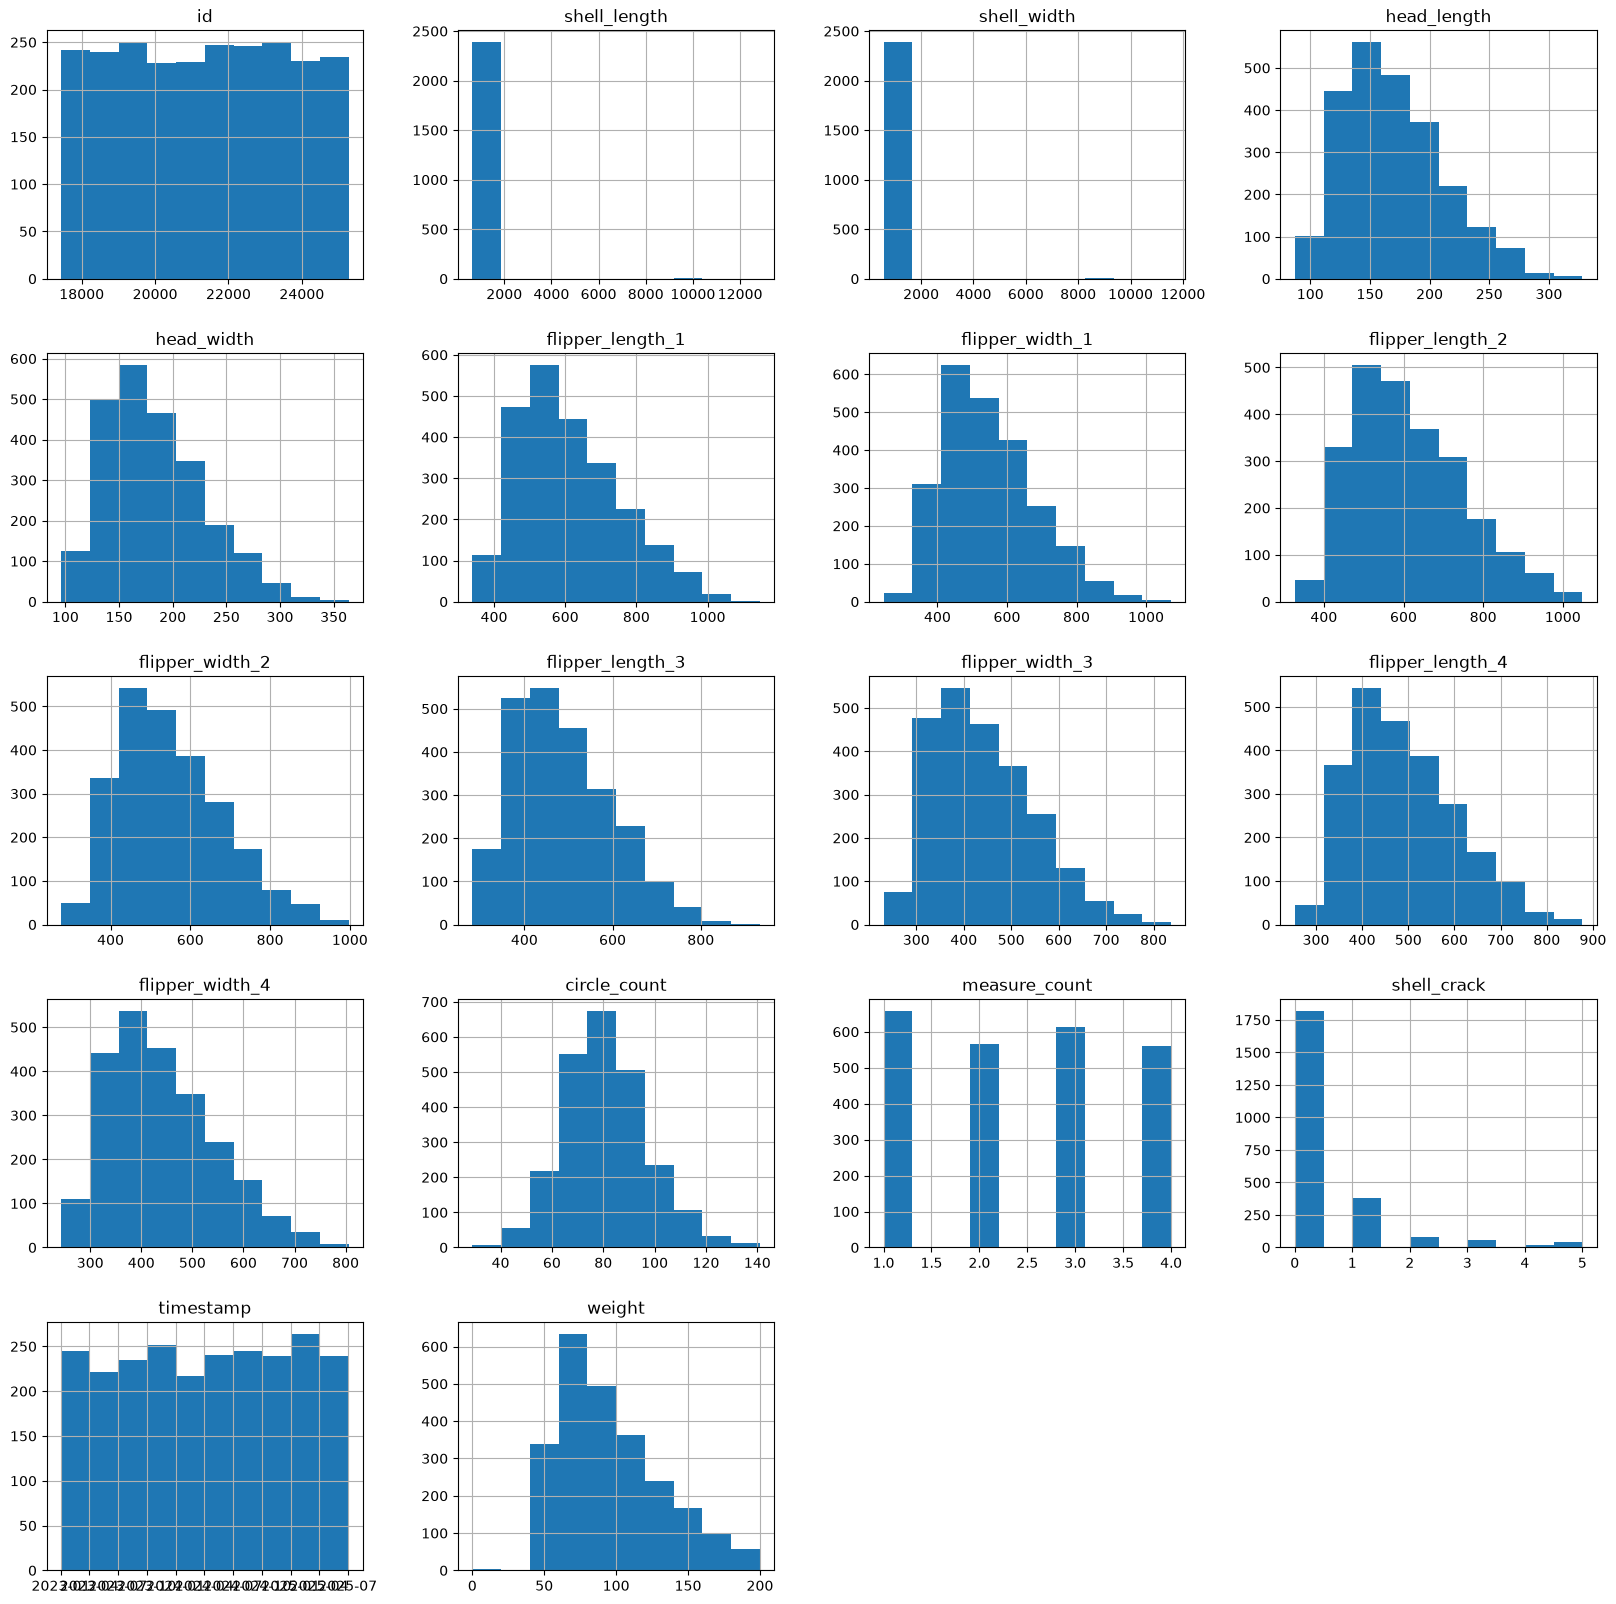

In [23]:
df.hist(figsize = (20,20))
plt.show()

Заметны аномалии/выбросы в столбцах `shell_length`, `shell_width` (здесь значения аномально высокие) и `weight` (здесь есть аномально низкие значения). Визуализируем более детально. Для начала пару `shell_length`, `shell_width`.

In [24]:
print(f"Количество уникальных значений: {df['shell_length'].nunique()}")
print(f"Минимум: {df['shell_length'].min()}")
print(f"Максимум: {df['shell_length'].max()}")
print(f"Дисперсия: {df['shell_length'].var()}")

Количество уникальных значений: 793
Минимум: 645.0
Максимум: 12840.0
Дисперсия: 330311.8456285876


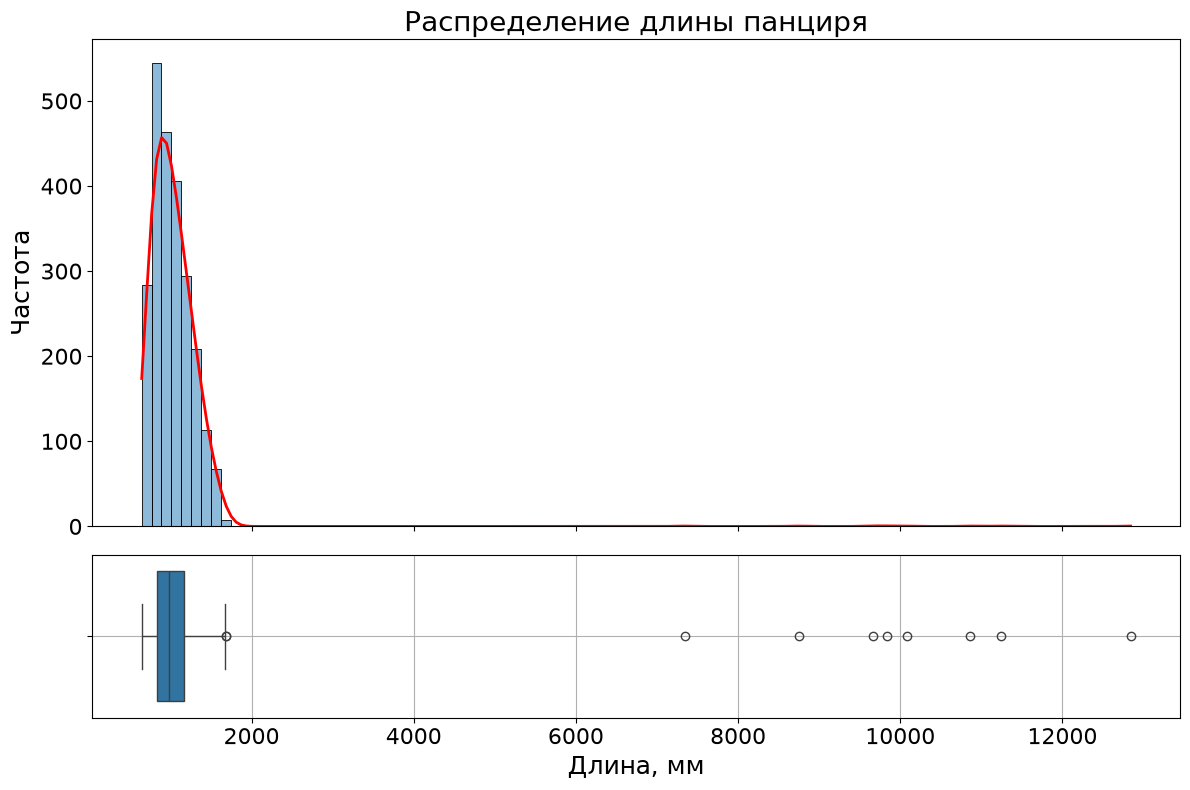

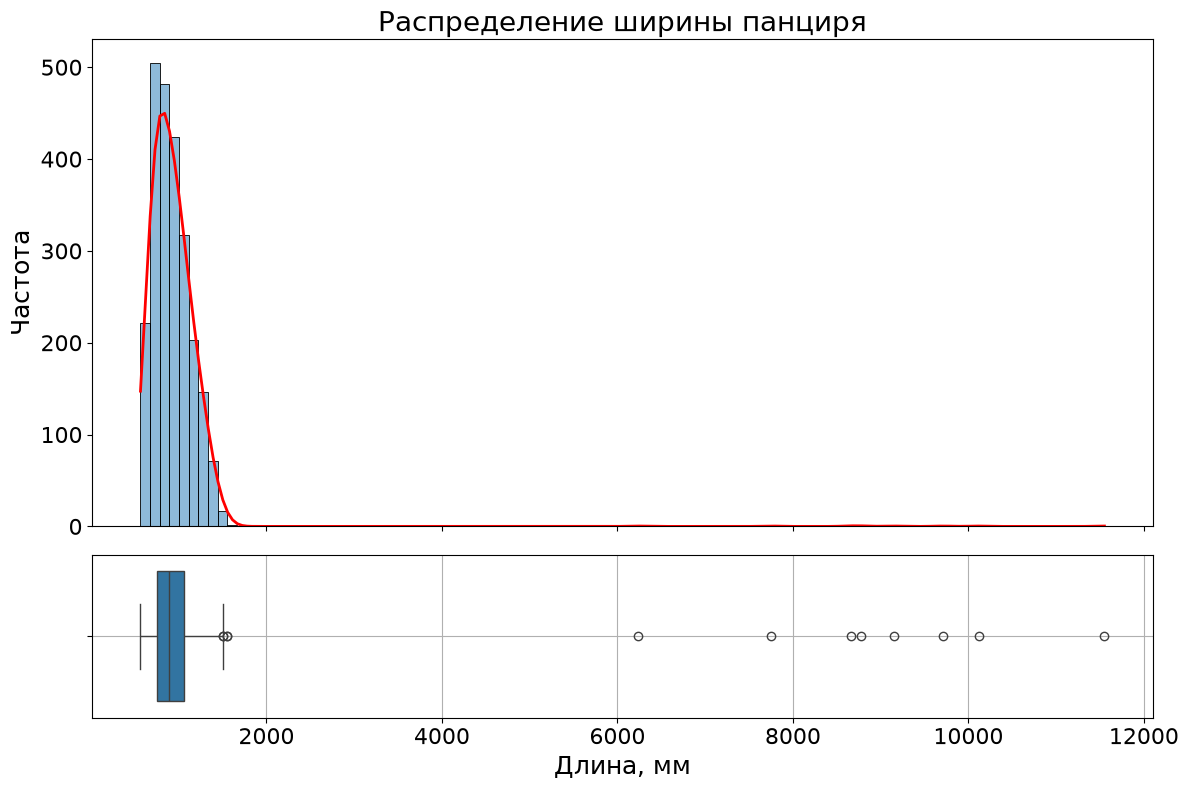

In [25]:
def hist_and_boxplot_plot(dataframe,column,title,xlabel,ylabel,kdeflag,bins = 100):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    sns.histplot(data=dataframe, x=column, kde=kdeflag, bins=bins, ax=ax1)
    ax1.set_title(title, fontsize=20)
    ax1.set_ylabel(ylabel, fontsize=18)
    ax1.tick_params(axis='both', labelsize=16)
    
    sns.boxplot(x=dataframe[column], ax=ax2)
    plt.xlabel(xlabel, fontsize=18)
    ax2.tick_params(axis='both', labelsize=16)
    plt.tight_layout()
    plt.grid()
    
    if kdeflag:
        kde_line = ax1.lines[-1]
        kde_line.set_color("red")
        kde_line.set_linewidth(2)
    
    plt.show()

hist_and_boxplot_plot(df,"shell_length","Распределение длины панциря","Длина, мм","Частота",True)
hist_and_boxplot_plot(df,"shell_width","Распределение ширины панциря","Длина, мм","Частота",True)

In [26]:
mask = (df['shell_length'] > 2000) | (df['shell_width'] > 2000)
df[mask]

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
53,23436,chelonia mydas,6e103cb141423f9c05256cf8acf42aaf,12840.0,11550,231.0,203.0,814,563,801,603,653.0,555.0,593.0,588.0,89,2,0.0,2024-12-15 12:32:54,127.917000
114,17912,chelonia mydas,ffb1fdb1ed00f2edb7495bd6bd219fcc,11240.0,10120,186.0,209.0,659,576,632,678,565.0,515.0,556.0,364.0,88,4,0.0,2023-02-26 12:04:29,110.142998
146,18477,chelonia mydas,995a4b32e7dd543ba81aaafe8cae8bca,10860.0,9710,179.0,175.0,662,597,703,493,535.0,458.0,511.0,460.0,70,2,0.0,2023-05-04 15:21:12,94.921997
370,23569,chelonia mydas,8ddad1855439e78a51e003080dc46d9b,9840.0,9150,160.0,139.0,614,499,541,599,482.0,477.0,501.0,409.0,65,2,0.0,2024-12-29 21:10:29,95.751999
718,20206,chelonia mydas,efa501f1195277f7e3d25e83fb0494fe,7340.0,6230,123.0,138.0,374,267,469,356,282.0,298.0,341.0,291.0,53,1,0.0,2023-11-26 14:09:17,53.604000
827,19720,chelonia mydas,5ed560389a5c963dd0b9efe5b1db798a,10080.0,8660,137.0,188.0,613,625,590,470,476.0,394.0,490.0,450.0,84,3,0.0,2023-10-04 19:17:44,89.346001
2176,23087,chelonia mydas,c134b99f0186e5b9bb0613bd73f75aa8,8750.0,7750,165.0,120.0,514,392,566,491,432.0,377.0,389.0,365.0,79,4,1.0,2024-10-30 03:36:57,78.448997
2241,23433,chelonia mydas,ec69e87434a551369aebec62917fc280,9660.0,8780,203.0,177.0,522,471,562,556,429.0,435.0,490.0,469.0,103,2,0.0,2024-12-15 06:31:35,83.639000


In [27]:
df.loc[mask, 'shell_length'] = df.loc[mask, 'shell_length'] / 10
df.loc[mask, 'shell_width'] = df.loc[mask, 'shell_width'] / 10

В условиях задачи предупреждали о подобных выбросах (значения умножены на 10 по ошибке), причем они встречаются одновременно в обоих столбцах, следовательно имеем право заменить значения на правильные.

Проверим по массе столбец:

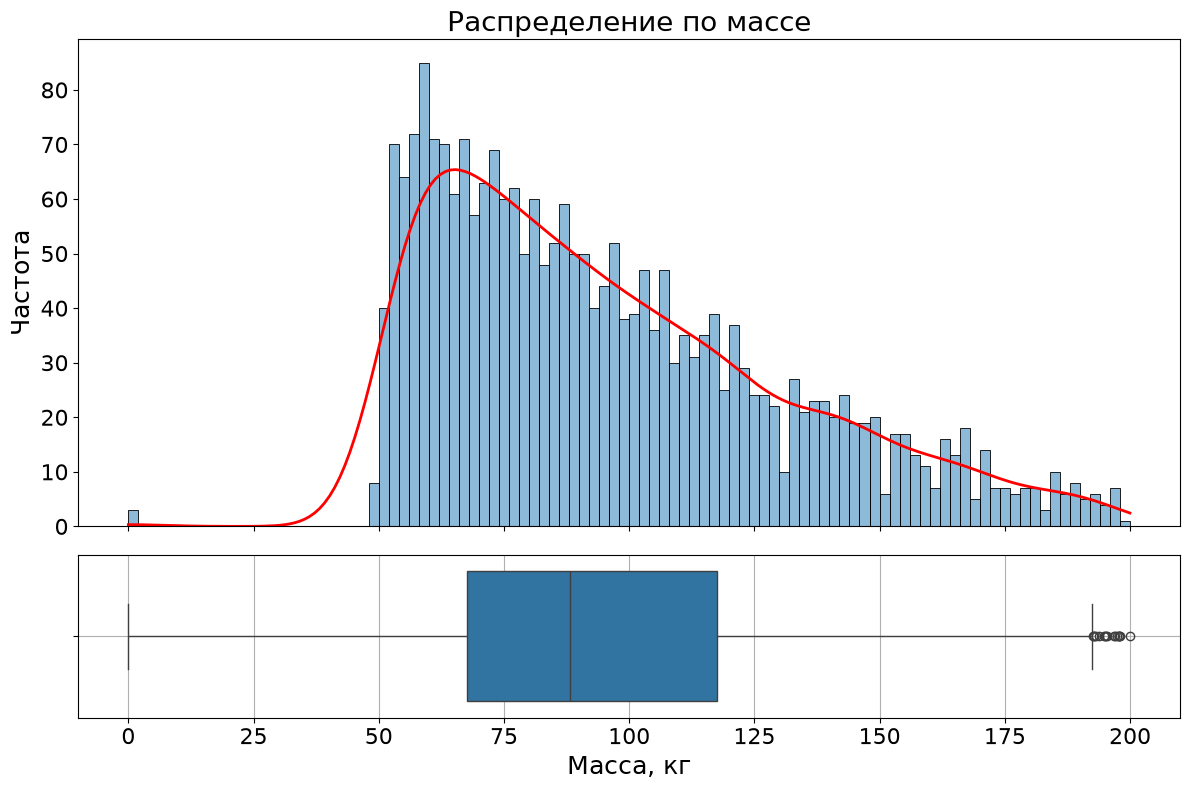

In [28]:
hist_and_boxplot_plot(df,"weight","Распределение по массе","Масса, кг","Частота",True)

In [29]:
df = df.query("weight > 1").copy()
df = df.reset_index()
df = df.drop(["index"], axis=1)

Были заметны аномальные массы, равные нулю. Заполнять их значениями не следует, т.к. это целевая переменная. Их мало, можно удалить.

Перед обучением модели следует провести регуляризацию по количественным признакам для улучшения качества модели. В настоящий момент времени многие признаки представлены в разных масштабах.

In [30]:
# Информация по удаленным строкам
num_row_after_clean = df.shape[0]
num_del = num_row_before_clean - num_row_after_clean
print(color.BOLD + color.BLUE + 'Количество строк в датафрейме до фильтрации: '  + color.END + str(num_row_before_clean))
print(color.BOLD + color.BLUE + 'Количество строк в датафрейме после фильтрации: '  + color.END + str(num_row_after_clean))
print(color.BOLD + color.BLUE + 'Количество удаленных строк и количество явных дубликатов: '  + color.END + str(num_del) + ', ' + str(num_duplicated))
print(color.BOLD + color.BLUE + 'Процент удаленных строк и процент явных дубликатов из них: '  + color.END 
      + str(round(100*(num_del/num_row_before_clean),2)) + '%, ' 
            + str(round(100*(num_duplicated/num_del),2)) + '%')

Количество строк в датафрейме до фильтрации: 2829
Количество строк в датафрейме после фильтрации: 2393
Количество удаленных строк и количество явных дубликатов: 436, 328
Процент удаленных строк и процент явных дубликатов из них: 15.41%, 75.23%


<a id='p4e'></a>

---

<span style="font-size: 18px;">**Корреляция между признаками**</span>

Перед проведением корреляционного анализа и оценки зависимости между признаками удалим [лишние признаки](p4b), которые не будут учавствовать в дальнейшем анализе, добавим признаки, характеризующие площадь соответствующей части тела черепахи, а также оптимизируем типы после очистки от пропусков и аномалий.

[К Содержимому проекта](#contents)

In [31]:
df["shell_square"] = 1.0 * df["shell_length"] * df["shell_width"]
df["head_square"] = 1.0 * df["head_length"] * df["head_width"]
for i in range(1,5):
    df[f"flipper_square_{i}"] = 1.0 *  df[f"flipper_length_{i}"] * df[f"flipper_width_{i}"]
    

df = df.drop(["id","binomial_name","registration_number","measure_count","timestamp"], axis=1)
for col in ['shell_length','shell_width','head_length','head_width','flipper_length_3','flipper_width_3','flipper_length_4','flipper_width_4','shell_crack','shell_square','head_square','flipper_square_1','flipper_square_2','flipper_square_3','flipper_square_4']:
    df[col] = pd.to_numeric(df[col], downcast='integer')

Проверим на корреляцию

In [32]:
def plot_heatmap(data,title,xlabel,ylabel,figsize = (6,6)):
    plt.figure(figsize=figsize)
    fig = sns.heatmap(data,
                      annot=True, # Отображаем численные значения в ячейках карты
                      fmt='.2f', # Форматируем значения корреляции: два знака после точки
                      cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                      linewidths=0.5, # Форматируем линию между ячейками карты
                      cbar=False # Отключаем цветовую шкалу
                      ,annot_kws={'size': 10}
                     )
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    fig.tick_params(axis='both', labelsize=12)    
    
    plt.show()

In [33]:
# interval_cols по сути указание на числовые столбцы, которые не нужно рассматривать как категории
correlation_matrix1 = df.phik_matrix(interval_cols = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight', 'shell_square', 'head_square', 'flipper_square_1', 'flipper_square_2', 'flipper_square_3', 'flipper_square_4'])
correlation_matrix_pearson = df.corr(method='pearson')
correlation_matrix_spearman = df.corr(method='spearman')

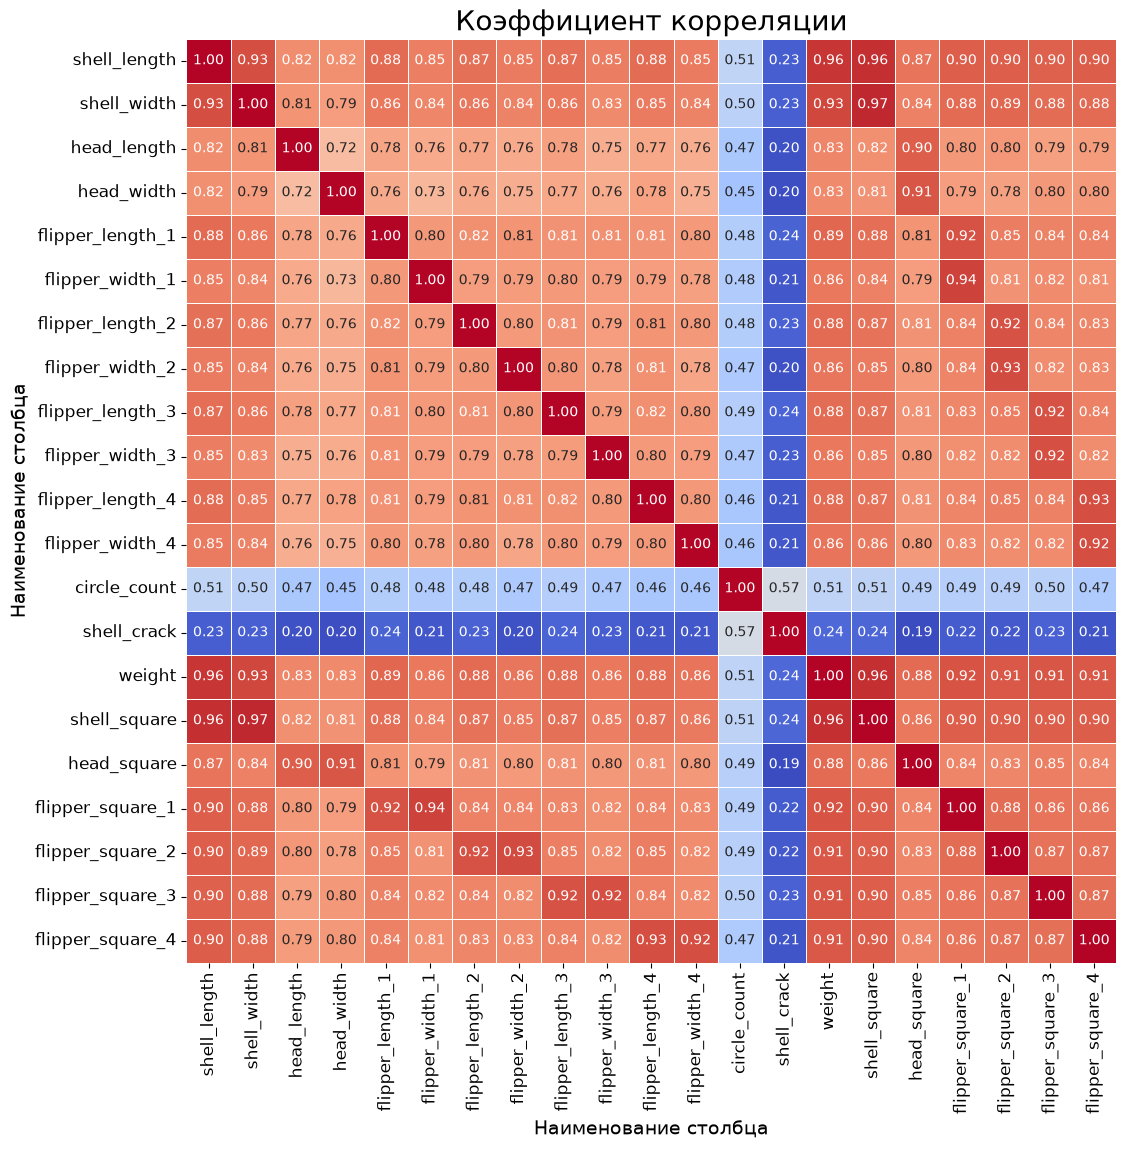

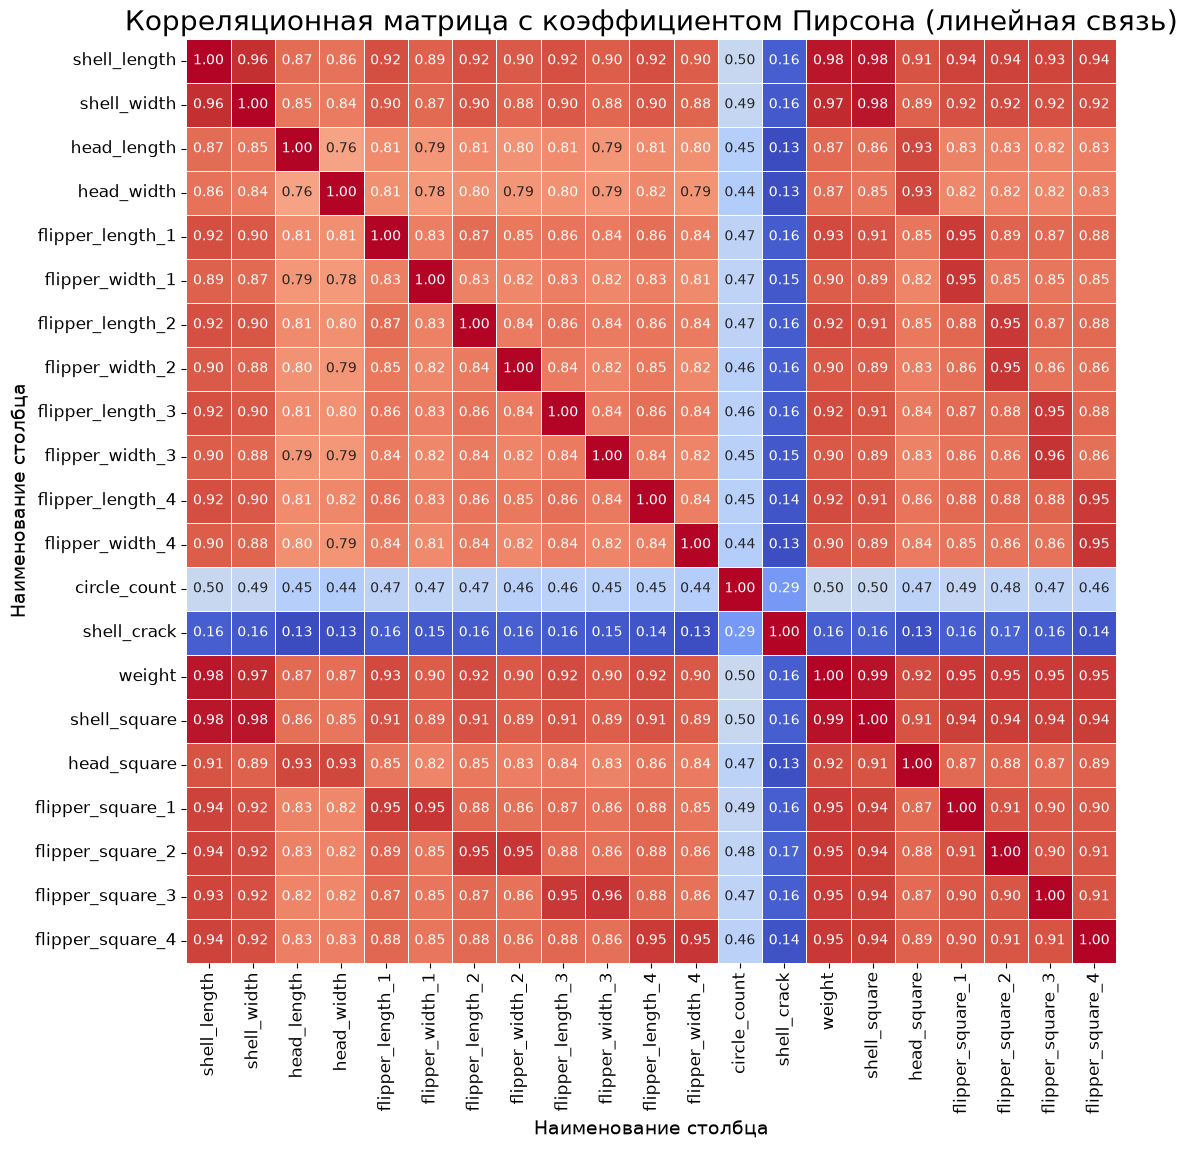

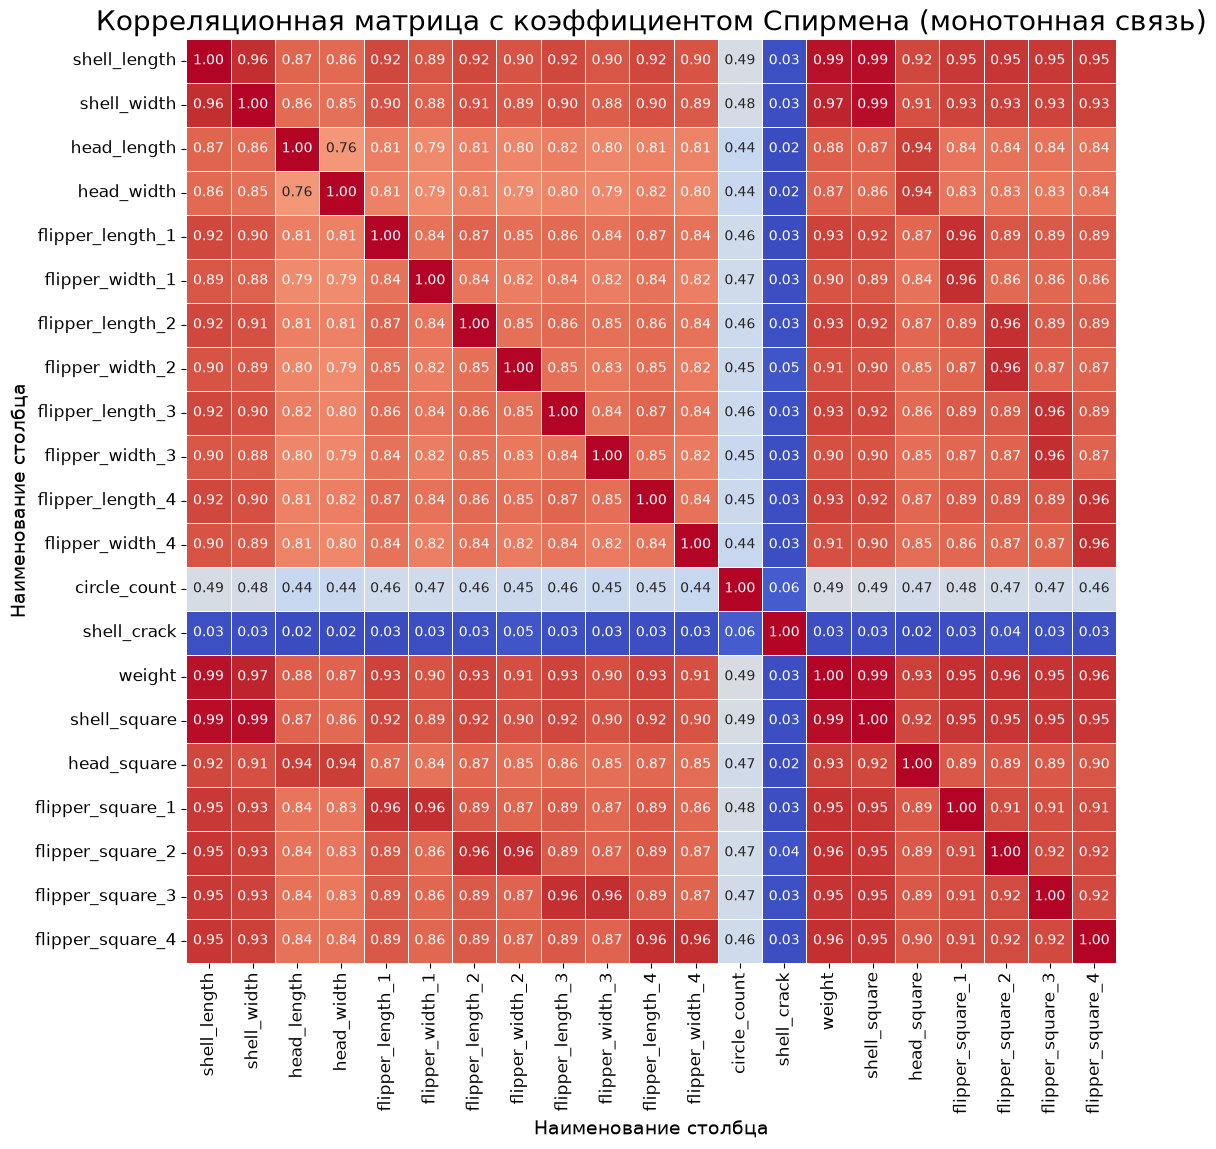

In [34]:
plot_heatmap(correlation_matrix1,'Коэффициент корреляции','Наименование столбца','Наименование столбца',figsize = (12,12))
plot_heatmap(correlation_matrix_pearson,'Корреляционная матрица с коэффициентом Пирсона (линейная связь)','Наименование столбца','Наименование столбца',figsize = (12,12))
plot_heatmap(correlation_matrix_spearman,'Корреляционная матрица с коэффициентом Спирмена (монотонная связь)','Наименование столбца','Наименование столбца',figsize = (12,12))

Заметна крайне сильная корреляция как в рамках коэффициента корреляции $\phi_k$, так и в рамках коэффициента Пирсона (линейная связь), как между признаками, так и между признаками и целевой переменной. Подобного рода связи стоит учитывать при выборе моделей. Если имеется сильная связь по Пирсону между некоторыми признаками, то использование аналитической линейной регерессии может привести к ошибочным результатам , т.к. с математической точки зрения столбцы будут практически линейно зависимы (следовательно, определитель матрицы близок к нулю), а значит обратную матрицу найти проблематично, а она используется в рамках аналитического решения. В итоговом отчете по шагу приводится стратегия по выбору моделей и разделению таблицы на признаки.

---

<span style="font-size: 18px;">**Проверка данныех на мультиколлинеарность**</span>

Для проверки на мультиколлинеарность используется коэффициент variance_inflation_factor (VIF). В рамках данного коэффициент для каждого признака строится регрессия этого признака на все остальные признаки. Если остальные признаки хорошо объясняют его значение, VIF получается большим - это признак мультиколлинеарности.

У VIF есть формула: $ \text{VIF} = \frac{1}{1-R^2_i}$. Здесь $R^2_i$ - коэффициент детерминации при регрессии i-го признака на все остальные признаки.

In [35]:
Xpr = df.drop(columns=['weight']).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,feature,VIF
15,shell_square,563.144730
0,const,486.140205
18,flipper_square_2,237.904719
20,flipper_square_4,218.682942
19,flipper_square_3,209.206813
17,flipper_square_1,199.657537
1,shell_length,178.845466
2,shell_width,168.858194
16,head_square,136.097053
8,flipper_width_2,74.867456


Традиционно, показатель значения показателя оценивают примерно так: 
- VIF $\approx$ 1 - мультиколлинеарности практически нет
- VIF $\in(1,5)$ допустимый уровень
- VIF $\in[5,10]$ заметная мультиколлинеарность
- VIF > 10 сильная мультиколлинеарность

В данном случае заметна действительно сильная мультиколлинеарность между почти всем признаками, кроме `circle_count` и `shell_crack`, они линейно-независимы от остальных признаков, что логично, т.к. количество кругов это скорее мера возраста черепахи, а `shell_crack` (количество трещин) связаны с некоторой случайностью и единичными событиями в жизни черепахи. Кроме того в данном случае присутствуют как площади, так и длины, на основе которых эти показатели расчитаны, что, возможно, приводит к такому росту показателей. Стоит исключить или площади или пары длина/ширина из анализируемых признаков и пересчитать VIF. Оставление только площадей кажется более логичным, т.к. в условиях задачи для характеристики части тела, вероятно, будет достаточно одного показателя.

In [36]:
Xpr = df.drop(columns=['shell_length','shell_width','head_length','head_width','flipper_length_1','flipper_width_1','flipper_length_2','flipper_width_2','flipper_length_3','flipper_width_3','flipper_length_4','flipper_width_4','weight']).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,feature,VIF
0,const,27.275666
3,shell_square,23.451242
8,flipper_square_4,10.084979
6,flipper_square_2,9.992190
5,flipper_square_1,9.441067
7,flipper_square_3,9.172104
4,head_square,6.310464
1,circle_count,1.418482
2,shell_crack,1.099789


После оставления информации по площадям показатели значительно упали, что подтверждает ранее приведенную догадку. Однако, заметна сильная мультиколлинеарность между частями признаков, что тоже объяснимо -  у данного вида черепах есть некоторые естественные пропорции между разными частями тела. Однако, модели все равно стоит обучать на данных признаках, т.к. модели, возможно, смогут уловить некоторые отклонения от стандартных пропорций тела черепахи и заложить их в итоговую массу. Например, в следствии некоторого несчастного случая черепаха потеряла часть своего плавника. Или у нее есть отклонение по размеру голову от стандарта для вида, что приводит к небольшому изменению массы в плюс или минус. Исходя из полученных результатов далее принято решение анализировать только признаки из последнего анализа по VIF (оставить площади, удалить пары).

<a id='p4f'></a>

---

### Итоговый отчет по результатам раздела

[К Содержимому проекта](#contents)

В рамках данного раздела была продолжены исследование и обработка данных об анализе черепах. Итоговый датафрейм `df` имеет 2393 строк и 21 столбец. Были получены следующие результаты:
- Из исходного датафрейма были извлечены черепахи, имеющий вид *Chelonia mydas*. Кроме того были оставлены строки с заполненной целевой переменной `weight`.
- Были обнаружены пропуски в разных столбцах. Ниже кратко описывается что было сделано с каждым из них:
    - `shell_crack` (количество трещин) пропуски были заполнены 0 (до заполнения 0 не было), т.к. отсутствие значения в данном столбце, вероятно, означает отсутствие трещин.
    - `measure_count` (количество измерений) пропуски были заполнены 1, т.к. есть факт хотя бы одного измерения, а именно строка в таблице.
    - `head_width` и `head_length`, `flipper_length_4` и `flipper_width_4`, `flipper_length_3` и `flipper_width_3`, и `shell_length` строки с пропусками в данных значениях были удалены. Пропусков в данных столбцах было немного (менее 4% суммарно), кроме того они были немного странные (всегда пропущены оба параметра в паре, если отсутствует информация об одном плавнике - 3, то нет информации и о 4 плавнике).
- Были обнаружено достаточно много явных дубликатов (328 строк из 2829). Они были удалены из датафрейма. Количество удаленных явных дубликатов составило 75.23% от общего количества удаленных строк после выделения вида *Chelonia mydas*.
- При проверки на выбросы были установлены выбросы в столбцах `shell_length`, `shell_width` и `weight`. В условиях задачи предупреждали о возможных выбросах по некоторым переменным (значения умножены на 10 по ошибке);  в столбцах `shell_length`, `shell_width` были они. Они были откорректированы путем деления на 10. Были заметны аномальные массы (`weight`), равные нулю. Заполнять их значениями не следует, т.к. это целевая переменная. Их мало (3), можно удалить.
- Из таблицы после анализа на пропуски, дубликаты и выбросы были удалены следующие столбцы:
    - `id`, `timestamp` и `registration_number`, т.к. исходя из смысла задачи они не должны влиять на целевую переменную.
    - `binomial_name`, т.к. в рамках исследования был оставлен один вид черепах.
    - `measure_count`, т.к. он имеет косвенную связь с `weight` и скорее связан с точностью измерения длин в выборке.
- Масштабы признаков зачастую сильно различаются, поэтому требуется нормализация (или через нормальное распределение или через min-max регуляризацию).
- Между признаками заметна сильная корреляция. В датафрейм были добавлены признаки пропорциональные площади соответствующей  части черепахи (панцирь, голова или ласты). Введенные признаки более точно характеризуют связь между весом и частью тела черепахи. Исходные пары признаков сильно связаны между собой и фактически пропорциональны. Наличие такой связи нежелательно для моделей машинного обучения. 
- Между признаками заметна также и сильная мультиколлинеарность, что может объяснятся наличием естественных пропорций для вида. Однако, возможно, что модели смогут уловить влияние отклонений в значениях некоторых признаков (например, был поврежден плавник, что уменьшит значение целевой переменной). Показатель VIF сокращается при учете только площадей, без пар длин/ширина. Если учитывать и площади и пары - значения коэффициента значительно увеличиваются. Данное поведение логично, т.к. по сути площади рассчитываются напрямую через формулу площади в которой есть значения длины и ширины. Поэтому пары признаков длина-ширина будут удалены из датафрейма. Исходя из полученных результатов принято решение разбить датафрейм на следующие наборы по столбцам:
    - Для наивной аналитической регрессии (`LinearRegression`) из исходного датафрейма будет оставлен единственный столбец `shell_square` (значение линейной корреляции между ним и целевым столбцом 0.99, практически линейная связь).
    - Для попытки более тонко уловить закономерности между параметрами будет создан второй датафрейм со следующими признаками: `shell_crack`, `shell_square`, `head_square`, `flipper_square_1`, `flipper_square_2`, `flipper_square_3`, `flipper_square_4`. В анализе будут использованы `LinearRegression`, `Lasso`, `Ridge` и `SGDRegressor`.
    - Еще одна попытка уловить более тонко влияние остальных признаков через добавление новых признаков, являющихся квадратами, кубами некоторых оригинальных признаков. В таком случае аппроксимация осуществляется в рамках полиномов более высоких порядков нежели чем в рамках классической регрессии.

<a id='p5'></a>

---

## Предобработка данных

1. Разделим данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%).
2. Обработаем пропуски.
3. Напишим функцию для стандартизации признаков.
4. Напишим функцию для нормализации признаков.

[К Содержимому проекта](#contents)

Перед разделением на выборки, учитывая [результаты](p4f) предыдущего раздела из исходного датафрейма уберем часть признаков, характеризующие пары длина-ширина для некоторой части тела. Оставим только признаки, характеризующие площадь это части.

In [37]:
#Разделение на выборки
X = df.drop(columns=['shell_length','shell_width','head_length','head_width','flipper_length_1','flipper_width_1','flipper_length_2','flipper_width_2','flipper_length_3','flipper_width_3','flipper_length_4','flipper_width_4','weight'])
y = df["weight"]
X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [38]:
# Вывод размеров
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train shape:     X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shape: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shape:      X = {X_test.shape}, y = {y_test.shape}")

Train size: 1435, Val size: 479, Test size: 479
Train shape:     X = (1435, 8), y = (1435,)
Validation shape: X = (479, 8), y = (479,)
Test shape:      X = (479, 8), y = (479,)


Пропуски были обработаны [ранее](p4c).

Ниже приводится нормализация признаков:

In [39]:
# На будущее есть скейлеры в библиотеке
# from sklearn.preprocessing import StandardScaler,MinMaxScaler
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_vals = X_train.min()
        max_vals = X_train.max()
        X_train_scaled = (X_train - min_vals) / (max_vals - min_vals)
        X_val_scaled = (X_val - min_vals) / (max_vals - min_vals)
        X_test_scaled = (X_test - min_vals) / (max_vals - min_vals)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

In [40]:
X_train_stand, X_val_stand, X_test_stand = scale_data(X_train, X_val, X_test, method='standard')
print("Сравнение статистик ДО и ПОСЛЕ стандартизации:\n")
for col in X_train.columns:
    original_min = X_train[col].min()
    original_max = X_train[col].max()
    original_mean = X_train[col].mean()
    
    standardized_min = X_train_stand[col].min()
    standardized_max = X_train_stand[col].max()
    standardized_mean = X_train_stand[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={standardized_min:.2f}, max={standardized_max:.2f}, mean={standardized_mean:.2f}\n")

Сравнение статистик ДО и ПОСЛЕ стандартизации:

circle_count:
  Было:    min=38.00, max=141.00, mean=81.40
  Стало:   min=-2.66, max=3.65, mean=0.00

shell_crack:
  Было:    min=0.00, max=5.00, mean=0.42
  Стало:   min=-0.44, max=4.76, mean=0.00

shell_square:
  Было:    min=407320.00, max=2500386.00, mean=992362.02
  Стало:   min=-1.34, max=3.46, mean=-0.00

head_square:
  Было:    min=10500.00, max=105952.00, mean=32880.46
  Стало:   min=-1.46, max=4.75, mean=0.00

flipper_square_1:
  Было:    min=99858.00, max=1021925.00, mean=355612.66
  Стало:   min=-1.56, max=4.07, mean=-0.00

flipper_square_2:
  Было:    min=108990.00, max=979054.00, mean=356413.27
  Стало:   min=-1.54, max=3.86, mean=-0.00

flipper_square_3:
  Было:    min=80864.00, max=634950.00, mean=227387.73
  Стало:   min=-1.42, max=3.95, mean=0.00

flipper_square_4:
  Было:    min=71599.00, max=688445.00, mean=228069.50
  Стало:   min=-1.50, max=4.42, mean=0.00



In [41]:
X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train, X_val, X_test, method='minmax')
print("Сравнение статистик ДО и ПОСЛЕ стандартизации:\n")
for col in X_train.columns:
    original_min = X_train[col].min()
    original_max = X_train[col].max()
    original_mean = X_train[col].mean()
    
    standardized_min = X_train_minmax[col].min()
    standardized_max = X_train_minmax[col].max()
    standardized_mean = X_train_minmax[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={standardized_min:.2f}, max={standardized_max:.2f}, mean={standardized_mean:.2f}\n")

Сравнение статистик ДО и ПОСЛЕ стандартизации:

circle_count:
  Было:    min=38.00, max=141.00, mean=81.40
  Стало:   min=0.00, max=1.00, mean=0.42

shell_crack:
  Было:    min=0.00, max=5.00, mean=0.42
  Стало:   min=0.00, max=1.00, mean=0.08

shell_square:
  Было:    min=407320.00, max=2500386.00, mean=992362.02
  Стало:   min=0.00, max=1.00, mean=0.28

head_square:
  Было:    min=10500.00, max=105952.00, mean=32880.46
  Стало:   min=0.00, max=1.00, mean=0.23

flipper_square_1:
  Было:    min=99858.00, max=1021925.00, mean=355612.66
  Стало:   min=0.00, max=1.00, mean=0.28

flipper_square_2:
  Было:    min=108990.00, max=979054.00, mean=356413.27
  Стало:   min=0.00, max=1.00, mean=0.28

flipper_square_3:
  Было:    min=80864.00, max=634950.00, mean=227387.73
  Стало:   min=0.00, max=1.00, mean=0.26

flipper_square_4:
  Было:    min=71599.00, max=688445.00, mean=228069.50
  Стало:   min=0.00, max=1.00, mean=0.25



<a id='p6'></a>

---

## Обучение моделей

1. Построим базовую модель (дамми), с которой будете сравнивать все остальные. 
2. Обучим несколько архитектур линейных моделей.

[К Содержимому проекта](#contents)

<a id='p6a'></a>

---

### Базовая модель (`dummy_mod`)

Она может быть получена разными способами. Для единообразия интерфейса с остальными моделями построим её в рамках аналитической линейной регрессии, где в качестве подаваемого признака рассматривается столбец с двумя значениями (любыми не равными), а в качестве целевой переменной также столбец со значениями, равными среднему значения целевой переменной из обучающей выборки. Аналитически, через две точки в рамках Евклидовой геометрии проходит одна прямая, поэтому у базовой модели будет равным нулю коэффициенты при всех признаках и отличный от нуля свободный член, равный среднему по обучающей выборке. Нормализация признаков для этой модели не нужна вовсе.

[К Содержимому проекта](#contents)

In [42]:
# Функция для оценки настоящего результата и результата модели
def calculate_metrics(y_true, y_pred, split = 'train', mod_name = 'unknown', scale = 'no scale'):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
            'Mod_name': mod_name,
            'Split' : split,
            'Scale' : scale,
            'MAE': round(mae,2),
            'R2': round(r2, 3),
            'RMSE': round(rmse, 2),
            'MAPE': round(mape * 100, 2),
            'MSE': round(mse,2)
           }

In [43]:
X_train_dummy_naive = pd.DataFrame(X_train['shell_square'])

train_mean = y_train.mean()
X_train_dummy = pd.DataFrame([[1],[2]], columns=['shell_square'])
y_train_dummy = pd.Series([train_mean,train_mean])

dummy_mod = LinearRegression()
dummy_mod.fit(X_train_dummy, y_train_dummy)
# Коэффициенты модели
print('Коэффициенты dummy модели: ' + str(dummy_mod.coef_) + ' ' + str(dummy_mod.intercept_))

y_train_pred = dummy_mod.predict(X_train_dummy_naive)
dummy_train_metrics = calculate_metrics(y_train, y_train_pred, mod_name = 'dummy')

print(color.BOLD + color.RED + "Метрики dummy на train:\n" + color.END, dummy_train_metrics)

Коэффициенты dummy модели: [0.] 97.14884948730469
Метрики dummy на train:
 {'Mod_name': 'dummy', 'Split': 'train', 'Scale': 'no scale', 'MAE': 28.46, 'R2': -0.0, 'RMSE': 34.89, 'MAPE': 32.05, 'MSE': 1217.21}


Полученные коэффициенты и метрики на обучающей выборки соответствуют ожиданиями. Коэффициент R2 близок к нулю, как и должно было быть. Результаты по остальным метрикам можно использовать как оценочные для других моделей.

<a id='p6b'></a>

---

### Наивная модель (`naive_mod`)

Данная модель предсказывает вес черепахи на основании самого большого коэффициента Пирсона между целевой переменной `weight` и оценкой площади панциря - `shell_square`, полученного [ранее](p4e). При создании датафрейма для обучения не требуется регуляризация, т.к. признак для обучения один.

[К Содержимому проекта](#contents)

In [44]:
naive_mod = LinearRegression()
naive_mod.fit(X_train_dummy_naive, y_train)
# Коэффициенты модели
print('Коэффициенты dummy модели: ' + str(naive_mod.coef_) + ' ' + str(naive_mod.intercept_))

y_train_pred = naive_mod.predict(X_train_dummy_naive)
naive_train_metrics = calculate_metrics(y_train, y_train_pred, mod_name = 'naive')
print(color.BOLD + color.RED + "Метрики naive на train:\n" + color.END, naive_train_metrics)

Коэффициенты dummy модели: [7.92054138e-05] 18.548395400082867
Метрики naive на train:
 {'Mod_name': 'naive', 'Split': 'train', 'Scale': 'no scale', 'MAE': 4.09, 'R2': 0.976, 'RMSE': 5.41, 'MAPE': 4.21, 'MSE': 29.22}


Значительно лучше по сравнению с `dummy_mod` и фактически укладывается в требования заказчика по метрикам на тестовой выборке: $\text{MAE}\le 5$ и $\text{R²} \ge 0.97$. Однако, полученное качество может быть получится улучшить и учесть более тонкие моменты, связанные с возрастом, повреждением панциря, размером ласт и головы.

<a id='p6c'></a>

---

### Аналитическая лейная регрессия для полного набора признаков (`standart_LR`)

В первой итерации стандартной модели рассмотрим обучение на нормализованной выборке. В качестве моделей регрессии сопоставим все четыре `LinearRegression`,`Lasso` (L1-регуляризация), `Ridge` (L2-регуляризация), `SGDRegressor` и подберем гиперпараметры для каждой из них. Начнем с `LinearRegression`.

[К Содержимому проекта](#contents)

In [45]:
def TrainLinearRegression(X_train,y_train,mod_name = 'standart_LR', scale = 'standart'):
    LR = LinearRegression()
    LR.fit(X_train, y_train)
    # Коэффициенты модели
    print('Коэффициенты ' + mod_name + ' модели: ' + str(LR.coef_) + ' ' + str(LR.intercept_))
    y_train_pred = LR.predict(X_train)
    train_metrics = calculate_metrics(y_train, y_train_pred, mod_name = mod_name, scale = scale)
    print(color.BOLD + color.RED + "Метрики " + mod_name + " на train, масштаб " + scale + ":\n" + color.END, train_metrics)
    return LR

In [46]:
standart_LR = TrainLinearRegression(X_train_stand,y_train,mod_name = 'standart_LR', scale = 'standart')

Коэффициенты standart_LR модели: [4.55351799e-01 5.72900800e-03 1.86593032e+01 2.85500643e+00
 3.84835172e+00 3.45459664e+00 3.39325672e+00 3.08772436e+00] 97.14883977909952
Метрики standart_LR на train, масштаб standart:
 {'Mod_name': 'standart_LR', 'Split': 'train', 'Scale': 'standart', 'MAE': 3.26, 'R2': 0.985, 'RMSE': 4.29, 'MAPE': 3.36, 'MSE': 18.39}


Справляется лучше наивной модели, влияние других факторов более тонко учтено. Посчитаем для не нормализованной и минмакс регулиризованной выборке.

In [47]:
print(color.BOLD + color.BLUE +'no scale выборка:\n'+ color.END)
standart_LR_nonorm = TrainLinearRegression(X_train,y_train,mod_name = 'standart_LR', scale = 'no scale')
print(color.BOLD + color.BLUE +'\nminmax выборка:\n'+ color.END)
standart_LR_minmax = TrainLinearRegression(X_train_minmax,y_train,mod_name = 'standart_LR', scale = 'minmax')

no scale выборка:

Коэффициенты standart_LR модели: [2.79145442e-02 5.95861703e-03 4.28639802e-05 1.85740011e-04
 2.35034381e-05 2.14378163e-05 3.29045176e-05 2.96172749e-05] 15.994506878740253
Метрики standart_LR на train, масштаб no scale:
 {'Mod_name': 'standart_LR', 'Split': 'train', 'Scale': 'no scale', 'MAE': 3.26, 'R2': 0.985, 'RMSE': 4.29, 'MAPE': 3.36, 'MSE': 18.39}

minmax выборка:

Коэффициенты standart_LR модели: [2.87519806e+00 2.97930852e-02 8.97171396e+01 1.77292555e+01
 2.16717447e+01 1.86522722e+01 1.82319325e+01 1.82692975e+01] 45.92975819180358
Метрики standart_LR на train, масштаб minmax:
 {'Mod_name': 'standart_LR', 'Split': 'train', 'Scale': 'minmax', 'MAE': 3.26, 'R2': 0.985, 'RMSE': 4.29, 'MAPE': 3.36, 'MSE': 18.39}


Метрики не изменились, однако, изменился учет признаков в модели и свободный коэффициент. При регуляризации стандартизацией он совпадает со средним по тестовой выборке в отличие от двух других случаев. Из полученных моделей далее на валидационной выборке будет сравниваться модель с регуляризацией через стандартизацию, т.к. она смотрится более гармонично.

<a id='p6d'></a>

---

### Lasso - модель (`Lasso`)

Посмотрим на `Lasso` для разных alpha.

[К Содержимому проекта](#contents)

In [48]:
def LassoRidgeTrain(X_train,y_train,modtype = 'Lasso',alphas = [0.001, 0.01, 0.1, 1, 10, 20, 50],max_iter=1000, tol=0.0001):
    best_alpha = None
    best_mae = float('inf')
    best_model = None
    for alpha in alphas:
        if modtype == 'Lasso':
            model = Lasso(alpha=alpha, max_iter=max_iter, tol=tol)
        elif modtype == 'Ridge':
            model = Ridge(alpha=alpha, max_iter=max_iter, tol=tol)
        else:
            print('Неверный тип модели')
            return None
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        mae_train = mean_absolute_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)
        mape = 100*mean_absolute_percentage_error(y_train, y_train_pred)
        mse = mean_squared_error(y_train, y_train_pred)
        
        print(f"Alpha: {alpha:.3f}, MAE: {mae_train:.3f}, R2: {r2_train:.3f}, MAPE: {mape:.3f}%, MSE: {mse:.3f}, Num_iter: {model.n_iter_}")
        # Сохраняем лучшую модель
        if mae_train < best_mae:
            best_mae = mae_train
            best_alpha = alpha
            best_model = model
    return best_model

In [49]:
standart_Lasso = LassoRidgeTrain(X_train_stand,y_train)

Alpha: 0.001, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: 128
Alpha: 0.010, MAE: 3.266, R2: 0.985, MAPE: 3.359%, MSE: 18.390, Num_iter: 118
Alpha: 0.100, MAE: 3.275, R2: 0.985, MAPE: 3.378%, MSE: 18.405, Num_iter: 113
Alpha: 1.000, MAE: 3.443, R2: 0.984, MAPE: 3.662%, MSE: 19.654, Num_iter: 110
Alpha: 10.000, MAE: 9.291, R2: 0.895, MAPE: 10.522%, MSE: 128.114, Num_iter: 42
Alpha: 20.000, MAE: 16.998, R2: 0.647, MAPE: 19.194%, MSE: 429.501, Num_iter: 2
Alpha: 50.000, MAE: 28.455, R2: 0.000, MAPE: 32.048%, MSE: 1217.212, Num_iter: 1


В таком виде лучше вовсе без регуляризации, т.к. MAE и R2 ухудшается с ростом $\alpha$. Попробуем другие выборки.

In [50]:
print(color.BOLD + color.BLUE +'no scale выборка:\n'+ color.END)
standart_Lasso_no = LassoRidgeTrain(X_train,y_train)
print(color.BOLD + color.BLUE +'\nminmax выборка:\n'+ color.END)
standart_Lasso_minmax = LassoRidgeTrain(X_train_minmax,y_train)

no scale выборка:

Alpha: 0.001, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: 356
Alpha: 0.010, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: 332
Alpha: 0.100, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: 263
Alpha: 1.000, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.395, Num_iter: 231
Alpha: 10.000, MAE: 3.277, R2: 0.985, MAPE: 3.367%, MSE: 18.542, Num_iter: 162
Alpha: 20.000, MAE: 3.277, R2: 0.985, MAPE: 3.367%, MSE: 18.542, Num_iter: 158
Alpha: 50.000, MAE: 3.277, R2: 0.985, MAPE: 3.367%, MSE: 18.542, Num_iter: 151

minmax выборка:

Alpha: 0.001, MAE: 3.265, R2: 0.985, MAPE: 3.358%, MSE: 18.390, Num_iter: 122
Alpha: 0.010, MAE: 3.270, R2: 0.985, MAPE: 3.367%, MSE: 18.399, Num_iter: 115
Alpha: 0.100, MAE: 3.362, R2: 0.984, MAPE: 3.518%, MSE: 19.179, Num_iter: 110
Alpha: 1.000, MAE: 5.818, R2: 0.957, MAPE: 6.529%, MSE: 52.356, Num_iter: 3
Alpha: 10.000, MAE: 28.455, R2: 0.000, MAPE: 32.048%, MSE: 1217.212, Num_iter: 1
Alpha: 20.000, MAE: 28.

Результат похож, лучше не становится.

<a id='p6e'></a>

---

### Ridge - модель (`Ridge`)

Рассмотрим `Ridge` на всех выборках сразу.

[К Содержимому проекта](#contents)

In [51]:
print(color.BOLD + color.BLUE +'standart выборка:\n'+ color.END)
standart_Ridge = LassoRidgeTrain(X_train_stand,y_train,modtype = 'Ridge')
print(color.BOLD + color.BLUE +'\nno scale выборка:\n'+ color.END)
standart_Ridge_no = LassoRidgeTrain(X_train,y_train,modtype = 'Ridge')
print(color.BOLD + color.BLUE +'\nminmax выборка:\n'+ color.END)
standart_Ridge_minmax = LassoRidgeTrain(X_train_minmax,y_train,modtype = 'Ridge')

standart выборка:

Alpha: 0.001, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 0.010, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 0.100, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 1.000, MAE: 3.266, R2: 0.985, MAPE: 3.358%, MSE: 18.393, Num_iter: None
Alpha: 10.000, MAE: 3.285, R2: 0.985, MAPE: 3.382%, MSE: 18.582, Num_iter: None
Alpha: 20.000, MAE: 3.315, R2: 0.984, MAPE: 3.417%, MSE: 18.951, Num_iter: None
Alpha: 50.000, MAE: 3.420, R2: 0.983, MAPE: 3.537%, MSE: 20.109, Num_iter: None

no scale выборка:

Alpha: 0.001, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 0.010, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 0.100, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 1.000, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 10.000, MAE: 3.265, R2: 0.985, MAPE: 3.357%, MSE: 18.390, Num_iter: None
Alpha: 20

Результат похож на Lasso, лучше без `Ridge`.

<a id='p6f'></a>

---

### SGDRegressor-модель (`SGDRegressor`)

Рассмотрим с 2-мя функциями ошибки (MSE и MAE), с разным шагом, на разных регуляризациях выборок и выберем лучшую. 

[К Содержимому проекта](#contents)

In [52]:
def SGDRegressorTrain(X_train,y_train,max_iter=1000, etas=[1e-5,1e-4,1e-3,1e-2,1e-1,1]):
    best_mae = float('inf')
    best_model = None
    for eta0 in etas:
        model_mse = SGDRegressor(eta0=eta0,max_iter=max_iter,tol=1e-4,random_state=42)
        model_mae = SGDRegressor(loss='epsilon_insensitive',epsilon=0.0,eta0=eta0,max_iter=max_iter,tol=1e-4,random_state=42)
        
        model_mse.fit(X_train, y_train)
        model_mae.fit(X_train, y_train)
        
        y_pred_mse = model_mse.predict(X_train)
        y_pred_mae = model_mae.predict(X_train)
        
        mse_mae = mean_absolute_error(y_train, y_pred_mse)
        mae_mae = mean_absolute_error(y_train, y_pred_mae)   
        mse_r2 = r2_score(y_train, y_pred_mse)
        mae_r2 = r2_score(y_train, y_pred_mae)
        mse_mape = 100*mean_absolute_percentage_error(y_train, y_pred_mse)
        mae_mape = 100*mean_absolute_percentage_error(y_train, y_pred_mae)
        mse_mse = mean_squared_error(y_train, y_pred_mse)
        mae_mse = mean_squared_error(y_train, y_pred_mae)
        
        print(f"Loss: MSE, eta: {eta0:.5f}, MAE: {mse_mae:.3f}, R2: {mse_r2:.3f}, MAPE: {mse_mape:.3f}%, MSE: {mse_mse:.3f}, Num_iter: {model_mse.n_iter_}")
        print(f"Loss: MAE, eta: {eta0:.5f}, MAE: {mae_mae:.3f}, R2: {mae_r2:.3f}, MAPE: {mae_mape:.3f}%, MSE: {mae_mse:.3f}, Num_iter: {model_mae.n_iter_}")
        print('')
        
        if mse_mae < best_mae:
            best_mae = mse_mae
            best_model = model_mse
        
        if mae_mae < best_mae:
            best_mae = mae_mae
            best_model = model_mae
    return best_model

In [53]:
print(color.BOLD + color.BLUE +'standart выборка:\n'+ color.END)
SGDReg_standart = SGDRegressorTrain(X_train_stand,y_train)

standart выборка:

Loss: MSE, eta: 0.00001, MAE: 55.893, R2: -1.591, MAPE: 63.863%, MSE: 3153.989, Num_iter: 1000
Loss: MAE, eta: 0.00001, MAE: 96.596, R2: -7.666, MAPE: 99.359%, MSE: 10547.995, Num_iter: 1000

Loss: MSE, eta: 0.00010, MAE: 3.602, R2: 0.981, MAPE: 3.656%, MSE: 23.000, Num_iter: 1000
Loss: MAE, eta: 0.00010, MAE: 91.621, R2: -6.896, MAPE: 93.594%, MSE: 9611.476, Num_iter: 1000

Loss: MSE, eta: 0.00100, MAE: 3.278, R2: 0.985, MAPE: 3.370%, MSE: 18.556, Num_iter: 1000
Loss: MAE, eta: 0.00100, MAE: 42.167, R2: -1.374, MAPE: 36.864%, MSE: 2889.916, Num_iter: 1000

Loss: MSE, eta: 0.01000, MAE: 3.256, R2: 0.985, MAPE: 3.323%, MSE: 18.538, Num_iter: 60
Loss: MAE, eta: 0.01000, MAE: 3.256, R2: 0.984, MAPE: 3.283%, MSE: 19.115, Num_iter: 725

Loss: MSE, eta: 0.10000, MAE: 3.293, R2: 0.985, MAPE: 3.363%, MSE: 18.731, Num_iter: 11
Loss: MAE, eta: 0.10000, MAE: 3.246, R2: 0.985, MAPE: 3.285%, MSE: 18.770, Num_iter: 47

Loss: MSE, eta: 1.00000, MAE: 4.105, R2: 0.971, MAPE: 3.993%, 

In [54]:
print(color.BOLD + color.BLUE +'\nminmax выборка:\n'+ color.END)
SGDReg_minmax = SGDRegressorTrain(X_train_minmax,y_train)


minmax выборка:

Loss: MSE, eta: 0.00001, MAE: 36.948, R2: -0.500, MAPE: 35.095%, MSE: 1826.053, Num_iter: 1000
Loss: MAE, eta: 0.00001, MAE: 96.259, R2: -7.602, MAPE: 99.031%, MSE: 10470.930, Num_iter: 1000

Loss: MSE, eta: 0.00010, MAE: 7.309, R2: 0.935, MAPE: 8.608%, MSE: 79.727, Num_iter: 1000
Loss: MAE, eta: 0.00010, MAE: 88.251, R2: -6.302, MAPE: 90.307%, MSE: 8887.628, Num_iter: 1000

Loss: MSE, eta: 0.00100, MAE: 3.710, R2: 0.980, MAPE: 3.836%, MSE: 23.983, Num_iter: 1000
Loss: MAE, eta: 0.00100, MAE: 16.987, R2: 0.568, MAPE: 15.068%, MSE: 525.254, Num_iter: 1000

Loss: MSE, eta: 0.01000, MAE: 3.419, R2: 0.983, MAPE: 3.508%, MSE: 20.381, Num_iter: 535
Loss: MAE, eta: 0.01000, MAE: 3.639, R2: 0.981, MAPE: 3.717%, MSE: 23.578, Num_iter: 1000

Loss: MSE, eta: 0.10000, MAE: 3.337, R2: 0.984, MAPE: 3.460%, MSE: 19.198, Num_iter: 75
Loss: MAE, eta: 0.10000, MAE: 3.506, R2: 0.982, MAPE: 3.552%, MSE: 22.059, Num_iter: 121

Loss: MSE, eta: 1.00000, MAE: 3.246, R2: 0.985, MAPE: 3.278%, 

Возможно, модель переобучилась и на валидационной выборке результаты будут хуже чем у других, но есть модель при стандартной регуляризации, имеющая лучшие показатели по MAE среди всех представленных до неё. При minmax результаты немного хуже и требуют большего начального шага.

In [55]:
print(color.BOLD + color.BLUE +'\nno scale выборка:\n'+ color.END)
SGDReg_noreg = SGDRegressorTrain(X_train,y_train,etas=[1e-2,1,10,100])


no scale выборка:

Loss: MSE, eta: 0.01000, MAE: 619350036613450170368.000, R2: -376174162590100428412963709109785329664.000, MAPE: 621848261187522396160.000%, MSE: 457883648310464305966138993495990295592960.000, Num_iter: 85
Loss: MAE, eta: 0.01000, MAE: 28508329.816, R2: -1196088217532.892, MAPE: 28698399.431%, MSE: 1455892751843109.750, Num_iter: 311

Loss: MSE, eta: 1.00000, MAE: 90836976905767757021184.000, R2: -8078972249858503551712982255145877367685120.000, MAPE: 91209534810283738923008.000%, MSE: 9833820757102582641457465468744313957456543744.000, Num_iter: 120
Loss: MAE, eta: 1.00000, MAE: 19739258490.429, R2: -388005286753266496.000, MAPE: 19806592239.220%, MSE: 472284632838866141184.000, Num_iter: 481

Loss: MSE, eta: 10.00000, MAE: 427106772325101058654208.000, R2: -180501233509981834507206204284534894159200256.000, MAPE: 428484232969274454441984.000%, MSE: 219708240340120935690932610621151889762941927424.000, Num_iter: 108
Loss: MAE, eta: 10.00000, MAE: 94980504309.561, 

Результаты совсем плохие, без нормализации лучше не пробовать.

<a id='p6g'></a>

---

### Модель с полиномами более высоких порядков (`Polynomial_model`)

В качестве эксперимента создадим модель, в которую входят количественные признаки, описываемые полиномами более высоких порядков. И посмотрим метрики для неё. Оставлю в тетради только лучшую на тестовой выборке для данной степени полинома.

[К Содержимому проекта](#contents)

In [56]:
def add_polynomial_features(max_degree, X_train, X_val, X_test, list_cols = X_train.columns):
    X_train_poly = X_train.copy()
    X_val_poly = X_val.copy()
    X_test_poly = X_test.copy()
    for col in list_cols:
        for i in range(2,max_degree+1):
            X_train_poly[f'{col}_deg_{i}'] = X_train[col] ** i
            X_val_poly[f'{col}_deg_{i}'] = X_val[col] ** i
            X_test_poly[f'{col}_deg_{i}'] = X_test[col] ** i
    return X_train_poly.sort_index(axis=1),X_val_poly.sort_index(axis=1),X_test_poly.sort_index(axis=1)

In [57]:
X_train_poly,X_val_poly,X_test_poly = add_polynomial_features(3, X_train_stand, X_val_stand, X_test_stand)
poly_mod = TrainLinearRegression(X_train_poly,y_train,mod_name = 'Poly', scale = 'standart')

Коэффициенты Poly модели: [ 6.38921075e-02 -1.73759731e-02  1.02111057e-01  4.41433737e+00
  8.49630617e-02 -1.20882838e-01  3.82268997e+00 -4.05633540e-01
  3.29920275e-02  3.75210858e+00 -1.52153352e-02 -5.52942235e-02
  3.68546182e+00 -3.12998236e-01 -4.90121143e-02  2.65652015e+00
  1.85570930e-01 -3.81954385e-02  1.85065066e-01 -6.92086547e-02
 -1.75638265e-03  1.89026652e+01  6.39222378e-02 -1.80133063e-01] 98.01916621971273
Метрики Poly на train, масштаб standart:
 {'Mod_name': 'Poly', 'Split': 'train', 'Scale': 'standart', 'MAE': 3.05, 'R2': 0.987, 'RMSE': 3.99, 'MAPE': 3.14, 'MSE': 15.9}


<a id='p7'></a>

---

## Сравнение моделей на валидационной выборке

1. Сравним построенные модели по метрикам на валидационной выборке.
2. Выберем лучшую модель по основной метрике на валидационной выборке. 
3. Напишим выводы о том, какая из моделей обладает лучшим качеством.

[К Содержимому проекта](#contents)

In [58]:
X_val_dummy_naive = pd.DataFrame(X_val['shell_square'])
y_val_pred = dummy_mod.predict(X_val_dummy_naive)
dummy_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'dummy', scale = 'no scale')

X_val_dummy_naive = pd.DataFrame(X_val['shell_square'])
y_val_pred = naive_mod.predict(X_val_dummy_naive)
naive_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'naive', scale = 'no scale')

y_val_pred = standart_LR.predict(X_val_stand)
standart_LR_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'LinearRegression_standart', scale = 'standart')

y_val_pred = standart_Lasso.predict(X_val_stand)
standart_Lasso_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'Lasso_standart', scale = 'standart')

y_val_pred = standart_Ridge.predict(X_val_stand)
standart_Ridge_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'Ridge_standart', scale = 'standart')

y_val_pred = SGDReg_standart.predict(X_val_stand)
SGDReg_standart_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'SGDRegressor_standart', scale = 'standart')

y_val_pred = poly_mod.predict(X_val_poly)
poly_mod_val_metrics = calculate_metrics(y_val, y_val_pred, split = 'val', mod_name = 'Polynomial_model', scale = 'standart')

list_of_dicts = [dummy_val_metrics,naive_val_metrics,standart_LR_val_metrics,standart_Lasso_val_metrics,standart_Ridge_val_metrics,SGDReg_standart_val_metrics,poly_mod_val_metrics]
columns_order = ['Mod_name', 'Split', 'Scale', 'MAE', 'RMSE', 'R2', 'MAPE', 'MSE']
valid_datafr = pd.DataFrame(list_of_dicts, columns=columns_order)
display(valid_datafr)

,Mod_name,Split,Scale,MAE,RMSE,R2,MAPE,MSE
0,dummy,val,no scale,28.63,34.57,-0.008,33.85,1194.87
1,naive,val,no scale,4.07,5.42,0.975,4.28,29.39
2,LinearRegression_standart,val,standart,3.12,4.04,0.986,3.34,16.32
3,Lasso_standart,val,standart,3.12,4.04,0.986,3.34,16.32
4,Ridge_standart,val,standart,3.12,4.04,0.986,3.34,16.32
5,SGDRegressor_standart,val,standart,3.09,4.04,0.986,3.27,16.28
6,Polynomial_model,val,standart,2.90,3.80,0.988,3.08,14.45


Лучшей моделью по ключевым показателем (MAE, R²) является `Polynomial_model`. По сравнению с предсказанием среднего (`dummy`) видны улучшения на порядок. Стоит отметить, что для `Polynomial_model` использовалась обычная аналитическая линейная регрессия, но с добавлением полиномиальных количественных признаков, что позволило более тонко учесть остальные признаки, кроме площади панциря, как это делается в `naive` модели. Однако, если нагрузка предполагается потоковой и модель может в дальнейшем дообучаться, то рекомендуется модель `SGDRegressor_standart`, которая использует градиент спуск в качестве основного метода поиска ответа. Поскольку в условиях задачи явно не указано про этот факт, то к проверке на тестовой выборке рекомендуется `Polynomial_model`.

<a id='p8'></a>

---

## Проверка лучшей модели на тестовой выборке

1. Проверим метрики лучшей модели на тестовой выборке.
2. Узнаем, есть ли признаки переобучения лучшей модели.
3. Определим, соответствует ли модель требованиям заказчика.

[К Содержимому проекта](#contents)

In [59]:
y_test_pred = poly_mod.predict(X_test_poly)
poly_mod_test_metrics = calculate_metrics(y_test, y_test_pred, split = 'test', mod_name = 'Polynomial_model', scale = 'standart')

list_of_dicts = [poly_mod_test_metrics]
columns_order = ['Mod_name', 'Split', 'Scale', 'MAE', 'RMSE', 'R2', 'MAPE', 'MSE']
valid_datafr = pd.DataFrame(list_of_dicts, columns=columns_order)
display(valid_datafr)

,Mod_name,Split,Scale,MAE,RMSE,R2,MAPE,MSE
0,Polynomial_model,test,standart,2.94,3.85,0.988,3.1,14.81


Протестированная здесь модель (`Polynomial_model`) соответствует требованиям заказчика, т.к.:
- является линеной моделью и позволяет написать простую функцию для прогнозирования;
- обеспечивает на всех выборках (в том числе тестовой в 20% от исходных данных) для целевой популяции зелёных морских черепах массой от 50 до 150 метрику MAE не более 5 кг (2.94 кг на тесте) и метрику R² не меньше 0.97 (0.988 на тесте). В относительных значениях отклонения предсказания от настоящих данных в среднем составляет 3.1% (MAPE на тесте).
- Обеспечена воспроизводимость экспериментов.

При учете работы с той же разновидностью черепах и при отсутствии дообучения на бою модель **рекомендуется к внедрению**.

---

## Оценка важности признаков <a id='p9'></a>

1. Оценим важность признаков по абсолютным значениям весов лучшей модели.
2. Напишим, какие признаки стали для модели более важными.

[К Содержимому проекта](#contents)

In [60]:
def get_fi(coefs, features):
    fi = pd.DataFrame({"feature": features, "coef": coefs})
    fi["coef_abs"] = fi["coef"].abs()
    fi.sort_values("coef_abs", ascending=True).plot(
        kind="barh", x="feature", y="coef_abs", figsize=(14, 14)
    )
    plt.title("Коэффициенты линейной регрессии", fontsize=20)
    plt.yticks(fontsize=14)
    plt.xlabel("Коэффициенты", fontsize=16)
    plt.ylabel("Признаки", fontsize=16)
    plt.show()

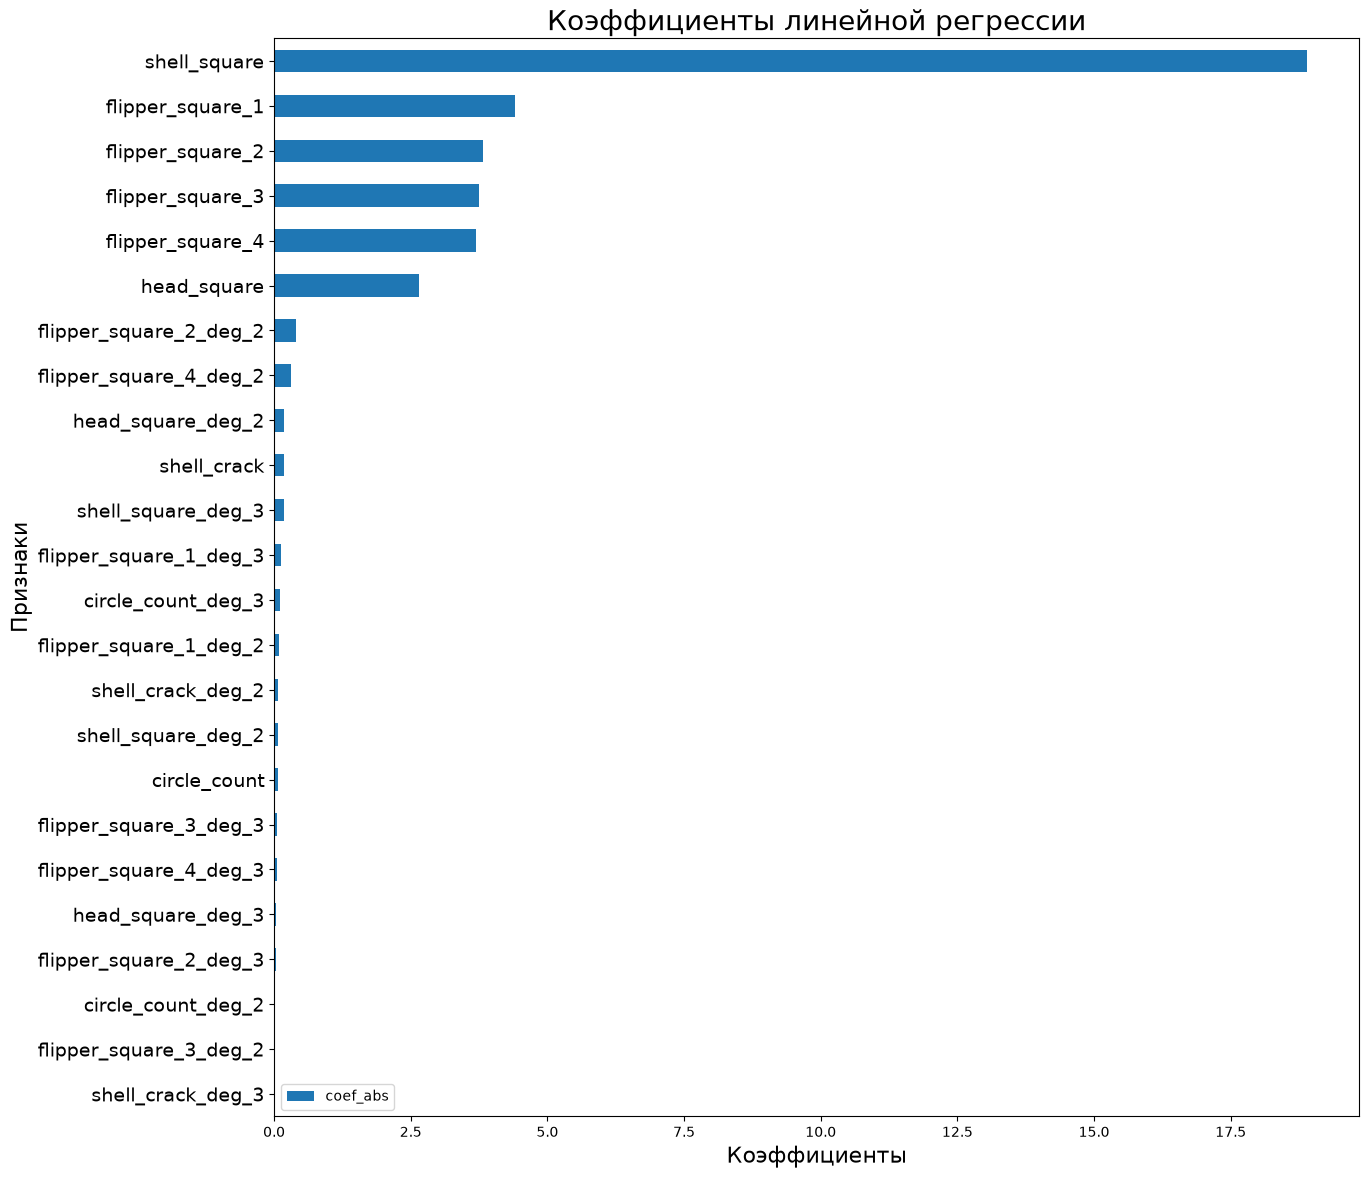

In [61]:
get_fi(poly_mod.coef_, list(X_train_poly.columns))

Наиболее важным признаком является площадь поверхности панциря (`shell_square`). Данный вывод еще следовал в рамках первичного анализа корреляции между признаками. В целом при большом размере панциря и тела черепахи это вполне ожидаемо. Следующими по важности являются площади ласт. Вероятно, у данного вида черепах они достаточно крупные. Далее важным показателем является площадь поверхности головы, что тоже вполне логично. Потом идут наборы производных признаков от площади ласт и головы (квадраты по этим признакам). Некую важность имеет наличие трещин, что вероятно связано с изменением массы поверхности панциря. Производным признак от количества кругов черепахи (полином 3 степени) имеет больший коэффициент, нежели чем сам исходный коэффициент для признака в первой степени `circle_count`. Это, возможно, указывает на более сложную зависимость целевой переменной от этого показателя, хотя в обоих случаях значение близко к нулю.

<a id='p10'></a>

---

## Сохранение артефактов модели

Сохраним построенную модель.

In [62]:
joblib.dump(poly_mod, '../models/Poly_mod.joblib')

loaded_model = joblib.load('./../models/Poly_mod.joblib')

y_test_pred = loaded_model.predict(X_test_poly)
poly_mod_test_metrics = calculate_metrics(y_test, y_test_pred, split = 'test', mod_name = 'Loaded_model', scale = 'standart')

list_of_dicts = [poly_mod_test_metrics]
columns_order = ['Mod_name', 'Split', 'Scale', 'MAE', 'RMSE', 'R2', 'MAPE', 'MSE']
valid_datafr = pd.DataFrame(list_of_dicts, columns=columns_order)
display(valid_datafr)

,Mod_name,Split,Scale,MAE,RMSE,R2,MAPE,MSE
0,Loaded_model,test,standart,2.94,3.85,0.988,3.1,14.81


<a id='p11'></a>

---

## Общие выводы и рекомендации по дальнейшей работе <a id='p11'></a>

[К Содержимому проекта](#contents)

В работе были изучены модели `LinearRegression`, `Lasso`, `Ridge`, `SGDRegressor`, а также модель `LinearRegression` с полиномиальными признаками (`Polynomial_model`). В качестве базовых моделей использовались `dummy` (возвращает среднее) и наивная модель (построена только на основе учета площади панциря).

Лучший результат показала `Polynomial_model` со стандартизацией признаков. На валидационной выборке она получила MAE = 2.90 кг, R² = 0.988, RMSE = 3.80 кг, MAPE = 3.08%. На тестовой выборке качество составило MAE = 2.94 кг, R² = 0.988, MAPE = 3.1%. Существенного ухудшения относительно валидационной выборки не наблюдается, поэтому признаков выраженного переобучения нет.

Модель соответствует требованиям заказчика (MAE $\le$ 5 кг, R² $\ge$ 0.97) и рекомендуется к внедрению при использовании для того же вида черепах и аналогичной обработки данных.

Наиболее важным признаком является площадь панциря (`shell_square`). Далее по значимости идут площади ласт и головы. Использование производных и полиномиальных признаков позволило модели учитывать более сложные зависимости между параметрами тела и массой. Среди способов обработки признаков лучшие результаты показала стандартизация в сочетании с полиномиальным расширением.

Полученный подход имеет перспективы для предсказания массы других видов черепах. Однако для каждого нового вида модель потребуется переобучить на соответствующих данных, поскольку разные виды могут иметь различные пропорции тела и, следовательно, другую зависимость массы от антропометрических признаков. В дальнейшем также можно исследовать ансамблевые модели, расширять обучающую выборку и проверять качество на новых независимых данных.

Ссылка на проект GitHub

https://github.com/AlexandrEvdokimov/Model_for_predicting_sea_turtle_mass